# xAquatic - Exposure and Effect Basic Analysis

(Thorsten Schad, version 2025.0.1.0)

This notebook provides basic analysis for exposure (PECsw and PECsed) and effect (individual level, GUTS, survival, LP50) characterisation for xAquatic experiments.
- percentile tables (csv, excel)
- plots: time series, box plots, contour, maps

The analysis currently focuses on a single Monte Carlo run.

Python preparation

In [1]:
%matplotlib widget
#%matplotlib inline

import h5py
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
from datetime import datetime
import os
from openpyxl import load_workbook
import geopandas as gpd
import contextily as ctx
import matplotlib.font_manager as fm
from mpl_toolkits.axes_grid1.anchored_artists import AnchoredSizeBar
from pathlib import Path
#from matplotlib_scalebar.scalebar import ScaleBar
#from cmath import log10
#import hvplot.pandas  # registers hvplot on pandas
#from scipy.interpolate import griddata

## User Input

Select Monte Carlo run

In [2]:
# !the outcome folder structure of xAquatic is expected: ...\run\'Experiment-ID'\mcs\'MC-ID'\store\arr.dat
# path to Monte Carlo run to be analysed (eg, copied from explorer, eg, C:\LocalWork\xAquaticRisk\run\rummen_toxswa_10yrs_lateMitigation_3\mcs\X3QP4MBM0QDHLTO1SS)
path = r'C:\LocalWork\xAquaticRisk\run\muenster28jul_arable1x75_noMitig_late_23feb\mcs\X3T5O6IVQFA1DYDI6N'
#parking lot
    # E:\xAquatic_Experiments_Store\run\funne_arableApril1x_Miti_1\mcs\X3HQQGC54AO6FTWF6V
    # E:\xAquatic_Experiments_Store\run\rummen_toxswa_10yrs_1\mcs\X3HEF7VE5LXT6FRFAV
    # E:\xAquatic_Experiments_Store\run\rummen_toxswa_10yrs_earlyMitigation_3\mcs\X3ESL54CYNDVEIHEC1
# path to related scenario (eg, C:\LocalWork\xAquaticRisk\scenario\Scenario-Rummen)
scenario_path = r'C:\LocalWork\xAquaticRisk\scenario\muenster-T-Di-02.5-20220429-postproceccing-toxwa'
# Scenario collection
    # E:\xAquaticRisk\scenario\Rummen
    # E:\xAquaticRisk\scenario\muenster-T-Di-02.5-20220429-postproceccing-toxwa
    # C:\LocalWork\xAquaticRisk\scenario\Bruchenbruecken
    # E:\xAquaticRisk\scenario\funne_250m_20y_01-cmf
    # E:\xAquaticRisk\scenario\GroteKemmelbeekTDI

# select scenario name
scenario_name = 'Muenster'   # see options in match statement below

Select outcome folder

In [3]:
#base processing and outcome folders
base_processing_folder = r'C:\LocalWork\temp'

Define Analysis Settings

In [4]:
# the scenario name helps to group some analysis settings that are specific to a scenario and typically re-occur in the analysis of experiments where it was used
#among scenario-specific settings are
#    - reach-list for individual time series plots
#    - reach-list for grouped time series plots

# xxx change to dictionary
#!currently, timeseries are only ploted for the first reach-ID or group of reach-IDs
reach_list_PEC_plot_timeseries = []
reach_list_PEC_groupplot_timeseries = []
plotzoom_from_time = ''
plotzoom_to_time = ''
match scenario_name:
        case 'Rummen':
            reach_list_PEC_plot_timeseries = [1388, 1610, 1738, 1505]
            reach_list_PEC_groupplot_timeseries = [1610, 1738, 1505]
            plotzoom_from_time = '1995-05-01'
            plotzoom_to_time = '1995-06-01'
        case 'Oudebeek':
            reach_list_PEC_plot_timeseries = [42]
        case 'Oudebeek-Beek7':
            reach_list_PEC_plot_timeseries = [42]
        case 'Muenster':
            reach_list_PEC_plot_timeseries = [154]   #standard (outlet): 154, sample ditch segment: 1071
            reach_list_PEC_groupplot_timeseries = [772, 575, 149]     # standard: 772, 575, 149; selection for Strahler-based PECsw analysis: 558, 560, 1028
            plotzoom_from_time = '2000-05-01'
            plotzoom_to_time = '2000-06-01'
        case 'Muschenheim':
            reach_list_PEC_plot_timeseries = [315, 230, 151, 149, 735]
            reach_list_PEC_groupplot_timeseries = [151, 149, 735]
        case 'Bruchenbruecken':
            reach_list_PEC_plot_timeseries = [660]
            reach_list_PEC_groupplot_timeseries = [652, 653, 4443]
            plotzoom_from_time = '1991-05-01'
            plotzoom_to_time = '1991-06-01'
        case 'Funne':
            reach_list_PEC_plot_timeseries = [12, 22, 527]    #[12, 22, [99,97,167], 527]
            reach_list_PEC_groupplot_timeseries = [99, 97, 167]
            plotzoom_from_time = '2010-05-01'
            plotzoom_to_time = '2010-06-01'
        case 'GKB':
            reach_list_PEC_plot_timeseries = [166]
            reach_list_PEC_groupplot_timeseries = [12, 144, 165]
            plotzoom_from_time = '2010-04-01'
            plotzoom_to_time = '2010-07-01'
        case _:
            raise Exception("Analysis stopped due to invalid scenario name")

#  percentile over time by Strahler-grouped reaches
boxplot_temporal_percentile = [0.9, 0.99, 1.0]

# PERCENTILE TABLES (spatial percentile over temporal percentiles (px(pt))
#set percentiles for PECsw and PECsed to be calculated over time
pec_temporal_percentiles = [0.1, 0.25, 0.5, 0.75, 0.9, 0.95, 0.99, 1.0]
#set percentiles for PECsw and PECsed to be calculated over space
pec_spatial_percentiles = [0.1, 0.25, 0.5, 0.75, 0.9, 0.95, 0.99, 1.0]
#set percentiles for GUTS to be calculated over time
guts_temporal_percentiles = [0.01, 0.05, 0.1, 0.25, 0.5, 0.75, 0.9, 0.95, 0.99, 1.0]
#set percentiles for GUTS to be calculated over space
guts_spatial_percentiles = [0.01, 0.05, 0.1, 0.25, 0.5, 0.75, 0.9, 0.95, 0.99, 1]

# Replace LP50 values outside reasonable threshold limits (rem.: might result from the fitting algorithm)
lower_LP50_threshold = 0.01
upper_LP50_threshold = 1000

Control

In [5]:
run_PEC_analysis = True
run_GUTS_analysis = True
exposed_streams_only_analysis = False

parking slot for analysis candidates

In [6]:
# candidates for analysis:
#E:\xAquaticRisk\run\muenster_arableOctNov2x625_Miti_1\mcs\X3INEHQLGQM8RFWDG7
#E:\xAquaticRisk\run\muschenheim_arableMayJune2x625_noMiti_txsw_1\mcs\X3PS0DISBHWM7MW719
#D:\xAquaticRisk\run\muenster_arableApril1x75_noMiti_1\mcs\X3CQ61DYK88F5BY6KA
#D:\xAquaticRisk\run\funne_arableApril1x_noMiti_1\mcs\X3W4SHH5394D5WKHEX
#E:\xAquaticRisk\run\funne_arableOctNov2x625_Miti_1\mcs\X3B5BA6V32VRFP2OXL
#C:\LocalWork\xAquaticRisk\run\rummen_toxswa_10yrs_1\mcs\X3HEF7VE5LXT6FRFAV
#C:\LocalWork\xAquaticRisk\run\rummen_toxswa_10yrs_Mitigation_1\mcs\X3CGXZ1GW8CXGZUT6B
#E:\xAquaticRisk\run\muschenheim_arableApril1x75_noMiti_txsw_1a\mcs\X31JBMYUGWXK312Q4G
#D:\xAquaticRisk\run\muenster_arableApril1x75_noMiti_1__L0hydro_10yrs\mcs\X3OAG3C0OSD9WSQR1Q
    #Scenario: D:\xAquaticRisk\scenario\muenster-T-Di-02.5-20220429-postproceccing-toxwa
#D:\xAquaticRisk\run\muenster_arableApril1x75_noMiti_1\mcs\X3CQ61DYK88F5BY6KA

#Rummen
    #C:\LocalWork\xAquaticRisk\run\rummen_toxswa_10yrs_1\mcs\X3HEF7VE5LXT6FRFAV
    #Analysis reach selection: 1388 1610 1738 1505
    #Szenario Rummen: C:\LocalWork\xAquaticRisk\scenario\Scenario-Rummen
    #C:\LocalWork\xAquaticRisk\run\rummen_toxswa_10yrs_late_1\mcs\X3EVKOUX93QTACCRFJ
    #C:\LocalWork\xAquaticRisk\run\rummen_toxswa_10yrs_late_mitigation_1\mcs\X3KJAU3M2X7BAIO72P
    #C:\LocalWork\xAquaticRisk\run\rummen_toxswa_10yrs_Mitigation_1\mcs\X3CGXZ1GW8CXGZUT6B
    #C:\LocalWork\xAquaticRisk\run\rummen_toxswa_10yrs_1\mcs\X3HEF7VE5LXT6FRFAV
    #C:\LocalWork\xAquaticRisk\run\rummen_toxswa_10yrs_late_1\mcs\X3EVKOUX93QTACCRFJ
    #C:\LocalWork\xAquaticRisk\run\rummen_toxswa_10yrs_Mitigation_1\mcs\X3CGXZ1GW8CXGZUT6B
#Muenster
    #Analysis reach selection: 154 772 575 149
    #scenario_path = r'E:\xAquaticRisk\scenario\muenster-T-Di-02.5-20220429-postproceccing-toxwa'
    #E:\xAquaticRisk\run\muenster_arableApril1x75_noMiti_1__L0hydro_2_test\mcs\X3LE1LRGX8LGHXQS69
    #E:\xAquaticRisk\run\muenster_arableApril1x75_noMiti_1__L0hydro_2\mcs\X3SEWKMR9F3BD281FM
    #E:\xAquaticRisk\run\muenster_arableApril1x75_noMiti_1__L0hydro_2_test\mcs\X3LE1LRGX8LGHXQS69
    #E:\xAquaticRisk\run\muenster_arableApril1x75_noMiti_1__L0hydro_2_5yrs\mcs\X3G3SQ8EB3JB5C1JBM
    #D:\xAquaticRisk\run\muenster_arableApril1x75_noMiti_1\mcs\X3CQ61DYK88F5BY6KA
    #E:\xAquaticRisk\run\muenster_arableApril1x75_noMiti_1__L0hydro_2_7yrs\mcs\X304USA5MCEEOWN41L
    #E:\xAquaticRisk\run\muenster_arableApril1x75_noMiti_1__L0hydro_2_9yrs\mcs\X325YY7XZCM4E077Y2
    #E:\xAquaticRisk\run\muenster_arableApril1x75_noMiti_1__L0hydro_2_10yrs\mcs\X3DT5PJ9LHPH3P4A25
#Funne
    #reach_list_analysis = [12, 22, [99,97,167], 527]
    #E:\xAquaticRisk\run\funne_arableApril1x75_noMiti_1_L0Hydro\mcs\X345TANVNFWCJ0IKIC
    #C:\LocalWork\xAquaticRisk\run\rummen_test_L0Hydro\mcs\X33J4YPQMSIHZZ6J3S
#Muschenheim
    #reach_list_analysis = [315 230 151 149 735]
    #Scenario Muschenheim: E:\xAquaticRisk\scenario\muschenheim-T-Di-v02.5-Preproceccing-20220331-cmf_20jul2025
    #E:\xAquaticRisk\run\muschenheim_arableApril1x75_noMiti_txsw_1a\mcs\X31JBMYUGWXK312Q4G
    #E:\xAquaticRisk\scenario\muschenheim-T-Di-v02.5-Preproceccing-20220331-cmf_20jul2025
    #E:\xAquaticRisk\run\muschenheim_arableMayJune2x625_noMiti_txsw_1\mcs\X3PS0DISBHWM7MW719
    #E:\xAquaticRisk\run\muschenheim_arableOctNov2x625_Miti_txsw_1\mcs\X3BY3JL0I3QLBRLW0N
    #E:\xAquaticRisk\run\muschenheim_arableOctNov2x625_noMiti_txsw_1\mcs\X3UTX529G43ITBM0GF
    #E:\xAquaticRisk\run\muschenheim_arableApril1x75_noMiti_txsw_PECsw_1y\mcs\X3YCHMGRY5ZLJ4K893


preparation of working folders

In [7]:
full_path = Path(path)

experiment_path = experiment = mc_run = ''
# Find index of 'run' in the parts
try:
    run_index = full_path.parts.index('run')
    experiment_path = Path(*full_path.parts[:run_index + 1])
    #print(experiment_path)
except ValueError:
    print("'run' folder not found in the path.")

# get the experiment ID
parts = full_path.parts
try:
    run_index = parts.index('run')
    mcs_index = parts.index('mcs')

    if mcs_index - run_index == 2:
        experiment = parts[run_index + 1]
        #print(experiment)
    else:
        print("Unexpected folder structure between 'run' and 'mcs'.")
except ValueError:
    print("Either 'run' or 'mcs' not found in the path.")

# get the mc run ID
try:
    mcs_index = parts.index('mcs')
    mc_run = parts[mcs_index + 1]
    #print(mc_run)
except (ValueError, IndexError):
    print("Could not find folder after 'mcs'.")

experiment_path = str(experiment_path)
experiment = str(experiment)
mc_run = str(mc_run)

In [8]:
#the HDF store
h5_data = experiment_path + r'\\' + experiment + r'\\mcs\\' + mc_run + r'\\store\\arr.dat'

# Create the analysis folder in the current working directory
timestamp_str = datetime.now().strftime('%Y%m%d%H%M%S')
current_analysis_folder = base_processing_folder + '\\' + experiment + '_' + mc_run + '__' + timestamp_str
os.makedirs(current_analysis_folder, exist_ok=True)

# Set the working directory
os.chdir(current_analysis_folder)

# Create an empty Excel file
empty_df = pd.DataFrame()
excel_filename = experiment + '_' + mc_run + ".xlsx"
empty_df.to_excel(excel_filename, index=False)

## Load Experiment Outcome

Load Exposure Data

In [9]:
# Open the file in read mode
with h5py.File(h5_data, 'r') as f:
    # List all top-level groups or datasets
    #print("Keys:", list(f.keys()))

    # Access a exposure dataset: ConLiqWatTgtAvg, ConLiqWatTgtAvgHrAvg
    reach_ids_pecsw = f[f['CascadeToxswa/ConLiqWatTgtAvg'].attrs['dim1_element_names']][:]
    starttime_pecsw = f['CascadeToxswa/ConLiqWatTgtAvg'].attrs['dim0_offset']
    df_pecsw = pd.DataFrame(f['CascadeToxswa/ConLiqWatTgtAvg'][:]) * 1000000    #multiply PECsw values by 1,000,000 to get to [ng/L] concentration units
    df_pecsed = pd.DataFrame(f['CascadeToxswa/CntSedTgt1'][:]) * 1000    #multiply PECsw values by 1,000,000 to get to [µg/kg] concentration units OR BY 1,000?
    #df[df.select_dtypes(include='number').columns] *= 1000


prepare PECsw and PECsed dataframe

In [10]:
# prepare time dimension as first table column; set as index
df_timeIndex_pecsw = pd.date_range(starttime_pecsw, periods=len(df_pecsw), freq='h')
df_pecsw.insert(0, 'time', df_timeIndex_pecsw)
df_pecsw.set_index('time', inplace=True)

df_timeIndex_pecsed = pd.date_range(starttime_pecsw, periods=len(df_pecsed), freq='h')
df_pecsed.insert(0, 'time', df_timeIndex_pecsw)
df_pecsed.set_index('time', inplace=True)

# make reach (stream segment) IDs data column head (assuming that reach-IDs of PECsed are the same as for PECsw
df_pecsw.columns = reach_ids_pecsw
df_pecsed.columns = reach_ids_pecsw

In [11]:
df_pecsw

,1,10,100,1000,1001,1002,1003,1004,1005,1006,...,990,991,992,993,994,995,996,997,998,999
time,,,,,,,,,,,,,,,,,,,,,
1991-01-01 01:00:00,0.0,0.0,0.000000,0.0,0.0,0.000000e+00,0.000000e+00,0.000000e+00,0.000000,0.000000,...,0.000000e+00,0.000000e+00,0.000000,0.000000e+00,0.000000e+00,0.0,0.0,0.0,0.0,0.0
1991-01-01 02:00:00,0.0,0.0,0.000000,0.0,0.0,0.000000e+00,0.000000e+00,0.000000e+00,0.000000,0.000000,...,0.000000e+00,0.000000e+00,0.000000,0.000000e+00,0.000000e+00,0.0,0.0,0.0,0.0,0.0
1991-01-01 03:00:00,0.0,0.0,0.000000,0.0,0.0,0.000000e+00,0.000000e+00,0.000000e+00,0.000000,0.000000,...,0.000000e+00,0.000000e+00,0.000000,0.000000e+00,0.000000e+00,0.0,0.0,0.0,0.0,0.0
1991-01-01 04:00:00,0.0,0.0,0.000000,0.0,0.0,0.000000e+00,0.000000e+00,0.000000e+00,0.000000,0.000000,...,0.000000e+00,0.000000e+00,0.000000,0.000000e+00,0.000000e+00,0.0,0.0,0.0,0.0,0.0
1991-01-01 05:00:00,0.0,0.0,0.000000,0.0,0.0,0.000000e+00,0.000000e+00,0.000000e+00,0.000000,0.000000,...,0.000000e+00,0.000000e+00,0.000000,0.000000e+00,0.000000e+00,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1993-12-30 20:00:00,0.0,0.0,0.000003,0.0,0.0,1.502500e-11,9.106320e-11,1.403250e-09,0.000001,0.000004,...,1.761200e-07,7.369040e-07,0.000005,2.854860e-07,2.962980e-07,0.0,0.0,0.0,0.0,0.0
1993-12-30 21:00:00,0.0,0.0,0.000003,0.0,0.0,1.483210e-11,8.958010e-11,1.374790e-09,0.000001,0.000004,...,1.730600e-07,7.279820e-07,0.000005,2.817400e-07,2.919130e-07,0.0,0.0,0.0,0.0,0.0
1993-12-30 22:00:00,0.0,0.0,0.000003,0.0,0.0,1.464240e-11,8.815550e-11,1.347870e-09,0.000001,0.000004,...,1.719280e-07,7.194360e-07,0.000005,2.786090e-07,2.887440e-07,0.0,0.0,0.0,0.0,0.0


Load Effect Data

In [12]:
# Open the file in read mode
with h5py.File(h5_data, 'r') as f:
    # List all top-level groups or datasets
    #print("Keys:", list(f.keys()))

    #...Effects/Survival
    starttime_guts = f['IndEffect_CascadeToxswa_SD_Species1/GutsSurvivalReaches'].attrs['dim0_offset']
    reach_ids_guts = f[f['IndEffect_CascadeToxswa_SD_Species1/GutsSurvivalReaches'].attrs['dim1_element_names']][:]
    df_guts_survival_sd_species1 = pd.DataFrame(f['IndEffect_CascadeToxswa_SD_Species1/GutsSurvivalReaches'][:, :, 10])
    df_guts_survival_sd_species2 = pd.DataFrame(f['IndEffect_CascadeToxswa_SD_Species2/GutsSurvivalReaches'][:, :, 10])
    df_guts_survival_sd_species3 = pd.DataFrame(f['IndEffect_CascadeToxswa_SD_Species3/GutsSurvivalReaches'][:, :, 10])
    df_guts_survival_it_species1 = pd.DataFrame(f['IndEffect_CascadeToxswa_IT_Species1/GutsSurvivalReaches'][:, :, 10])
    df_guts_survival_it_species2 = pd.DataFrame(f['IndEffect_CascadeToxswa_IT_Species2/GutsSurvivalReaches'][:, :, 10])
    df_guts_survival_it_species3 = pd.DataFrame(f['IndEffect_CascadeToxswa_IT_Species3/GutsSurvivalReaches'][:, :, 10])
    #...Effects/LP50s
    starttime_LP50 = f['IndEffect_LP50_CascadeToxswa_SD_Species1/LP50'].attrs['dim0_offset']
    reach_ids_LP50 = f[f['IndEffect_LP50_CascadeToxswa_SD_Species1/LP50'].attrs['dim1_element_names']][:]
    df_guts_LP50_sd_species1 = pd.DataFrame(f['IndEffect_LP50_CascadeToxswa_SD_Species1/LP50'][:])
    df_guts_LP50_sd_species2 = pd.DataFrame(f['IndEffect_LP50_CascadeToxswa_SD_Species2/LP50'][:])
    df_guts_LP50_sd_species3 = pd.DataFrame(f['IndEffect_LP50_CascadeToxswa_SD_Species3/LP50'][:])
    df_guts_LP50_it_species1 = pd.DataFrame(f['IndEffect_LP50_CascadeToxswa_IT_Species1/LP50'][:])
    df_guts_LP50_it_species2 = pd.DataFrame(f['IndEffect_LP50_CascadeToxswa_IT_Species2/LP50'][:])
    df_guts_LP50_it_species3 = pd.DataFrame(f['IndEffect_LP50_CascadeToxswa_IT_Species3/LP50'][:])

special: analysis of artefacts

In [13]:
# high PECsw artefacts analysis:
#get time and reachID where values are above a given threshold
'''
results = (
    df_pecsw.where(df_pecsw > 100)
            .stack()  # keeps only >100, converts to Series with MultiIndex (row, column)
            .reset_index()
            .rename(columns={"level_0": "row", "level_1": "column", 0: "value"})
            .to_dict("records")
)
results
'''

'\nresults = (\n    df_pecsw.where(df_pecsw > 100)\n            .stack()  # keeps only >100, converts to Series with MultiIndex (row, column)\n            .reset_index()\n            .rename(columns={"level_0": "row", "level_1": "column", 0: "value"})\n            .to_dict("records")\n)\nresults\n'

In [14]:
# high PECsw artefacts analysis:
#get time and reachID where values are above a given threshold - same functionality as above, but more oldfashioned stile
'''
#analyse cells with values above a certain value
mask = df_pecsw > 100
rows, cols = np.where(mask)

for r, c in zip(rows, cols):
    row_label = df_pecsw.index[r]
    col_label = df_pecsw.columns[c]
    value = df_pecsw.iloc[r, c]
    #print(f"Value {value} at row '{row_label}', column '{col_label}'")

results = [
    {"row": df_pecsw.index[r], "column": df_pecsw.columns[c], "value": df_pecsw.iloc[r, c]}
    for r, c in zip(*np.where(mask))
]

results_df = pd.DataFrame(results)
results_df
'''

'\n#analyse cells with values above a certain value\nmask = df_pecsw > 100\nrows, cols = np.where(mask)\n\nfor r, c in zip(rows, cols):\n    row_label = df_pecsw.index[r]\n    col_label = df_pecsw.columns[c]\n    value = df_pecsw.iloc[r, c]\n    #print(f"Value {value} at row \'{row_label}\', column \'{col_label}\'")\n\nresults = [\n    {"row": df_pecsw.index[r], "column": df_pecsw.columns[c], "value": df_pecsw.iloc[r, c]}\n    for r, c in zip(*np.where(mask))\n]\n\nresults_df = pd.DataFrame(results)\nresults_df\n'

prepare GUTS dataframes

In [15]:
# prepare time dimension as first table column; set as index
df_timeIndex_guts = pd.date_range(datetime(starttime_guts, 1, 1), periods=len(df_guts_survival_sd_species1), freq='YE')
#Survival
df_guts_survival_sd_species1.insert(0, 'time', df_timeIndex_guts)
df_guts_survival_sd_species1.set_index('time', inplace=True)
df_guts_survival_sd_species2.insert(0, 'time', df_timeIndex_guts)
df_guts_survival_sd_species2.set_index('time', inplace=True)
df_guts_survival_sd_species3.insert(0, 'time', df_timeIndex_guts)
df_guts_survival_sd_species3.set_index('time', inplace=True)
df_guts_survival_it_species1.insert(0, 'time', df_timeIndex_guts)
df_guts_survival_it_species1.set_index('time', inplace=True)
df_guts_survival_it_species2.insert(0, 'time', df_timeIndex_guts)
df_guts_survival_it_species2.set_index('time', inplace=True)
df_guts_survival_it_species3.insert(0, 'time', df_timeIndex_guts)
df_guts_survival_it_species3.set_index('time', inplace=True)
# make reach (stream segment) IDs data column head
df_guts_survival_sd_species1.columns = reach_ids_guts
df_guts_survival_sd_species2.columns = reach_ids_guts
df_guts_survival_sd_species3.columns = reach_ids_guts
df_guts_survival_it_species1.columns = reach_ids_guts
df_guts_survival_it_species2.columns = reach_ids_guts
df_guts_survival_it_species3.columns = reach_ids_guts

#LP50s
df_guts_LP50_sd_species1.insert(0, 'time', df_timeIndex_guts)
df_guts_LP50_sd_species1.set_index('time', inplace=True)
df_guts_LP50_sd_species2.insert(0, 'time', df_timeIndex_guts)
df_guts_LP50_sd_species2.set_index('time', inplace=True)
df_guts_LP50_sd_species3.insert(0, 'time', df_timeIndex_guts)
df_guts_LP50_sd_species3.set_index('time', inplace=True)
df_guts_LP50_it_species1.insert(0, 'time', df_timeIndex_guts)
df_guts_LP50_it_species1.set_index('time', inplace=True)
df_guts_LP50_it_species2.insert(0, 'time', df_timeIndex_guts)
df_guts_LP50_it_species2.set_index('time', inplace=True)
df_guts_LP50_it_species3.insert(0, 'time', df_timeIndex_guts)
df_guts_LP50_it_species3.set_index('time', inplace=True)
# make reach (stream segment) IDs data column head
df_guts_LP50_sd_species1.columns = reach_ids_guts
df_guts_LP50_sd_species2.columns = reach_ids_guts
df_guts_LP50_sd_species3.columns = reach_ids_guts
df_guts_LP50_it_species1.columns = reach_ids_guts
df_guts_LP50_it_species2.columns = reach_ids_guts
df_guts_LP50_it_species3.columns = reach_ids_guts

In [16]:
(df_guts_LP50_sd_species1 < 0).sum().sum()



np.int64(34)

adapt LP50 (as resulting from fitting algorithm)
- unreasonable low or high values
- negative values
- error codes by nan

In [17]:
# As at present there is no detailed information on error codes from the LP50 fitting algorithm (like -99, -997, -998, -999) all values below 0 are set to NaN
#df_guts_LP50_sd_species1.replace(-99, np.nan, inplace=True)
#df_guts_LP50_sd_species2.replace(-99, np.nan, inplace=True)
#df_guts_LP50_sd_species3.replace(-99, np.nan, inplace=True)
#df_guts_LP50_it_species1.replace(-99, np.nan, inplace=True)
#df_guts_LP50_it_species2.replace(-99, np.nan, inplace=True)
#df_guts_LP50_it_species3.replace(-99, np.nan, inplace=True)
df_guts_LP50_sd_species1[df_guts_LP50_sd_species1 < 0] = np.nan
df_guts_LP50_sd_species2[df_guts_LP50_sd_species2 < 0] = np.nan
df_guts_LP50_sd_species3[df_guts_LP50_sd_species3 < 0] = np.nan
df_guts_LP50_it_species1[df_guts_LP50_it_species1 < 0] = np.nan
df_guts_LP50_it_species2[df_guts_LP50_it_species2 < 0] = np.nan
df_guts_LP50_it_species3[df_guts_LP50_it_species3 < 0] = np.nan


# Replace LP50 values outside reasonable threshold limits (rem.: might result from the fitting algorithm)
df_guts_LP50_sd_species1[df_guts_LP50_sd_species1 < lower_LP50_threshold] = lower_LP50_threshold
df_guts_LP50_sd_species1[df_guts_LP50_sd_species1 > upper_LP50_threshold] = upper_LP50_threshold
df_guts_LP50_sd_species2[df_guts_LP50_sd_species2 < lower_LP50_threshold] = lower_LP50_threshold
df_guts_LP50_sd_species2[df_guts_LP50_sd_species2 > upper_LP50_threshold] = upper_LP50_threshold
df_guts_LP50_sd_species3[df_guts_LP50_sd_species3 < lower_LP50_threshold] = lower_LP50_threshold
df_guts_LP50_sd_species3[df_guts_LP50_sd_species3 > upper_LP50_threshold] = upper_LP50_threshold
df_guts_LP50_it_species1[df_guts_LP50_it_species1 < lower_LP50_threshold] = lower_LP50_threshold
df_guts_LP50_it_species1[df_guts_LP50_it_species1 > upper_LP50_threshold] = upper_LP50_threshold
df_guts_LP50_it_species2[df_guts_LP50_it_species2 < lower_LP50_threshold] = lower_LP50_threshold
df_guts_LP50_it_species2[df_guts_LP50_it_species2 > upper_LP50_threshold] = upper_LP50_threshold
df_guts_LP50_it_species3[df_guts_LP50_it_species3 < lower_LP50_threshold] = lower_LP50_threshold
df_guts_LP50_it_species3[df_guts_LP50_it_species3 > upper_LP50_threshold] = upper_LP50_threshold

In [18]:
df_guts_LP50_sd_species1

,1,10,100,1000,1001,1002,1003,1004,1005,1006,...,990,991,992,993,994,995,996,997,998,999
time,,,,,,,,,,,,,,,,,,,,,
1991-12-31,1000.0,1000.0,4.148875,1000.0,1000.0,76.304241,16.460271,21.696794,11.950447,4.357063,...,1000.000000,5.700013,0.641005,10.500932,10.684582,1000.0,1000.0,1000.0,1000.0,1000.0
1992-12-31,1000.0,1000.0,8.275142,1000.0,1000.0,1000.000000,1000.000000,1000.000000,2.507022,1.237406,...,32.487993,12.358933,9.415797,163.720842,165.301637,1000.0,1000.0,1000.0,1000.0,1000.0
1993-12-31,1000.0,1000.0,10.971793,1000.0,1000.0,1000.000000,1000.000000,1000.000000,1.474590,0.935866,...,1000.000000,16.685446,0.789683,11.480126,11.361331,1000.0,1000.0,1000.0,1000.0,1000.0


## Exposure Analysis

### Conservative Assessment Switch - Move From Catchment-scale Assessment to Focusing Exposed Stream Segments (and times) only

Include only those stream segments that have PECsw>0 at least once in the simulation period and time steps when at least von stream segment has PECsw>0

In [19]:
if exposed_streams_only_analysis == True:
    # 1. identify segments (columns) with at least one PECsw > 0
    valid_segs = df_pecsw.gt(0).any(axis=0)
    # 2. identify time steps (rows) with at least one PECsw > 0
    valid_times = df_pecsw.gt(0).any(axis=1)
    # 3. filter the DataFrame
    df_pecsw = df_pecsw.loc[valid_times, valid_segs]

    valid_segs = df_pecsed.gt(0).any(axis=0)
    valid_times = df_pecsed.gt(0).any(axis=1)
    df_pecsed = df_pecsed.loc[valid_times, valid_segs]

### Percentiles by Reach over time (t) [ng/L]

In [20]:
pecsw_percentiles_byReachOverTime = df_pecsw.quantile(pec_temporal_percentiles)
pecsed_percentiles_byReachOverTime = df_pecsed.quantile(pec_temporal_percentiles)
pecsw_percentiles_byReachOverTime


,1,10,100,1000,1001,1002,1003,1004,1005,1006,...,990,991,992,993,994,995,996,997,998,999
0.10,0.0,0.0,0.000003,0.0,0.0,3.956188e-11,2.165813e-10,2.909001e-09,0.000001,0.000003,...,0.000000,8.352904e-07,0.000019,0.000001,0.000001,0.0,0.0,0.0,0.0,0.0
0.25,0.0,0.0,0.000014,0.0,0.0,1.059750e-09,6.488825e-09,3.101650e-08,0.000008,0.000018,...,0.000000,3.500960e-06,0.000117,0.000007,0.000007,0.0,0.0,0.0,0.0,0.0
0.50,0.0,0.0,0.000068,0.0,0.0,1.426140e-08,8.507485e-08,4.408210e-07,0.000041,0.000097,...,0.000000,2.409840e-05,0.000704,0.000043,0.000044,0.0,0.0,0.0,0.0,0.0
0.75,0.0,0.0,0.000670,0.0,0.0,4.057637e-07,2.403413e-06,7.029205e-06,0.000377,0.000890,...,0.000000,2.465333e-04,0.004929,0.000310,0.000328,0.0,0.0,0.0,0.0,0.0
0.90,0.0,0.0,0.005060,0.0,0.0,9.220674e-06,5.420795e-05,8.996391e-05,0.002962,0.006696,...,0.000036,2.097672e-03,0.040299,0.002453,0.002574,0.0,0.0,0.0,0.0,0.0
0.95,0.0,0.0,0.014948,0.0,0.0,6.210002e-05,3.600346e-04,5.276747e-04,0.008592,0.019886,...,0.000210,5.882793e-03,0.093796,0.005707,0.005927,0.0,0.0,0.0,0.0,0.0
0.99,0.0,0.0,0.129469,0.0,0.0,7.406115e-04,4.312222e-03,6.457105e-03,0.058756,0.140497,...,0.003309,4.579590e-02,0.643274,0.041069,0.041805,0.0,0.0,0.0,0.0,0.0
1.00,0.0,0.0,1.839390,0.0,0.0,6.242310e-01,2.308810e+00,4.929480e-01,37.428600,30.307300,...,8.730110,4.192510e+01,31.553100,3.657730,1.706470,0.0,0.0,0.0,0.0,0.0


Spatial percentiles (over reaches) of temporal percentiles

In [21]:
# Function to calculate percentiles for a row
def row_percentiles(row):
    return pd.Series(np.percentile(row, [p * 100 for p in pec_spatial_percentiles]), index=[f"Px{int(p * 100)}" for p in pec_spatial_percentiles])

# Apply to each row
PECsw_percentiles_x_t = pecsw_percentiles_byReachOverTime.apply(row_percentiles, axis=1)
PECsed_percentiles_x_t = pecsed_percentiles_byReachOverTime.apply(row_percentiles, axis=1)

PECsw_percentiles_x_t

,Px10,Px25,Px50,Px75,Px90,Px95,Px99,Px100
0.10,0.0,0.000000,5.708924e-07,0.000007,0.000021,0.000024,0.000094,0.001458
0.25,0.0,0.000000,3.657510e-06,0.000036,0.000099,0.000113,0.000503,0.005902
0.50,0.0,0.000000,2.745570e-05,0.000198,0.000504,0.000588,0.002791,0.032666
0.75,0.0,0.000000,2.580352e-04,0.002009,0.004873,0.005302,0.023340,0.263997
0.90,0.0,0.000014,2.433203e-03,0.017042,0.035168,0.039584,0.178395,1.166029
0.95,0.0,0.000070,7.557734e-03,0.049845,0.108758,0.127754,0.476923,2.501801
0.99,0.0,0.000741,6.037462e-02,0.379196,0.653327,0.870786,3.161586,7.375041
1.00,0.0,0.102665,6.450630e+00,35.627500,139.927800,282.589000,781.992360,3131.270000


write to Excel

In [22]:

# Export as new sheet into existing excel file
# Load your existing workbook and sheet names
book = load_workbook(excel_filename)
sheet_name_pecsw = "PECsw_percentiles_x_t"
sheet_name_pecsed = "PECsed_percentiles_x_t"
# Create ExcelWriter, pointing to existing file and workbook
with pd.ExcelWriter(excel_filename, engine='openpyxl', mode='a', if_sheet_exists='replace') as writer:
    # Write to Excel
    PECsw_percentiles_x_t.to_excel(writer, sheet_name=sheet_name_pecsw, index=True)
    PECsed_percentiles_x_t.to_excel(writer, sheet_name=sheet_name_pecsed, index=True)

    # Format numeric columns
    worksheet = writer.sheets[sheet_name_pecsw]
    worksheet.cell(row=1, column=1).value = "perc_x: right / perc_t: down"
    for row in worksheet.iter_rows(min_row=2, min_col=2, max_col=30, max_row=30):
        for cell in row:
            cell.number_format = '0.0000'  # Two decimal places
    worksheet = writer.sheets[sheet_name_pecsed]
    worksheet.cell(row=1, column=1).value = "perc_x: right / perc_t: down"
    for row in worksheet.iter_rows(min_row=2, min_col=2, max_col=30, max_row=30):
        for cell in row:
            cell.number_format = '0.0000'  # Two decimal places


## Effect Analysis

Effect Percentiles by Reach over time (t)

Effects by entire Catchment or only exposed stream segments

In [23]:
if exposed_streams_only_analysis == True:
    # 1. identify segments (columns) with at least one PECsw > 0
    #valid_segs = df_pecsw.gt(0).any(axis=0)
    # 3. filter the DataFrames
    #df_guts_survival_sd_species1 = df_guts_survival_sd_species1.loc[:, (df_pecsw > 0).any(axis=0)]
    reaches_pecsw_gt_zero = df_pecsw.columns[(df_pecsw > 0).any(axis=0)]
    df_guts_survival_sd_species1 = df_guts_survival_sd_species1[reaches_pecsw_gt_zero]
    df_guts_survival_sd_species2 = df_guts_survival_sd_species2[reaches_pecsw_gt_zero]
    df_guts_survival_sd_species3 = df_guts_survival_sd_species3[reaches_pecsw_gt_zero]
    df_guts_survival_it_species1 = df_guts_survival_it_species1[reaches_pecsw_gt_zero]
    df_guts_survival_it_species2 = df_guts_survival_it_species2[reaches_pecsw_gt_zero]
    df_guts_survival_it_species3 = df_guts_survival_it_species3[reaches_pecsw_gt_zero]
    df_guts_LP50_sd_species1 = df_guts_LP50_sd_species1[reaches_pecsw_gt_zero]
    df_guts_LP50_sd_species2 = df_guts_LP50_sd_species2[reaches_pecsw_gt_zero]
    df_guts_LP50_sd_species3 = df_guts_LP50_sd_species3[reaches_pecsw_gt_zero]
    df_guts_LP50_it_species1 = df_guts_LP50_it_species1[reaches_pecsw_gt_zero]
    df_guts_LP50_it_species2 = df_guts_LP50_it_species2[reaches_pecsw_gt_zero]
    df_guts_LP50_it_species3 = df_guts_LP50_it_species3[reaches_pecsw_gt_zero]

In [24]:
#effect percentiles by reach over time
guts_surv_sd_sp1_perc_byReachOverTime = df_guts_survival_sd_species1.quantile(guts_temporal_percentiles)
guts_surv_sd_sp2_perc_byReachOverTime = df_guts_survival_sd_species2.quantile(guts_temporal_percentiles)
guts_surv_sd_sp3_perc_byReachOverTime = df_guts_survival_sd_species3.quantile(guts_temporal_percentiles)
guts_surv_it_sp1_perc_byReachOverTime = df_guts_survival_it_species1.quantile(guts_temporal_percentiles)
guts_surv_it_sp2_perc_byReachOverTime = df_guts_survival_it_species2.quantile(guts_temporal_percentiles)
guts_surv_it_sp3_perc_byReachOverTime = df_guts_survival_it_species3.quantile(guts_temporal_percentiles)
guts_LP50_sd_sp1_perc_byReachOverTime = df_guts_LP50_sd_species1.quantile(guts_temporal_percentiles)
guts_LP50_sd_sp2_perc_byReachOverTime = df_guts_LP50_sd_species2.quantile(guts_temporal_percentiles)
guts_LP50_sd_sp3_perc_byReachOverTime = df_guts_LP50_sd_species3.quantile(guts_temporal_percentiles)
guts_LP50_it_sp1_perc_byReachOverTime = df_guts_LP50_it_species1.quantile(guts_temporal_percentiles)
guts_LP50_it_sp2_perc_byReachOverTime = df_guts_LP50_it_species2.quantile(guts_temporal_percentiles)
guts_LP50_it_sp3_perc_byReachOverTime = df_guts_LP50_it_species3.quantile(guts_temporal_percentiles)

In [25]:
guts_surv_sd_sp1_perc_byReachOverTime

,1,10,100,1000,1001,1002,1003,1004,1005,1006,...,990,991,992,993,994,995,996,997,998,999
0.01,1.0,1.0,0.904260,1.0,1.0,1.0,0.990172,0.998630,0.660583,0.502258,...,1.0,0.941683,0.337615,0.983307,0.984950,1.0,1.0,1.0,1.0,1.0
0.05,1.0,1.0,0.909908,1.0,1.0,1.0,0.990975,0.998741,0.671719,0.510325,...,1.0,0.945101,0.344797,0.983719,0.985297,1.0,1.0,1.0,1.0,1.0
0.10,1.0,1.0,0.916968,1.0,1.0,1.0,0.991977,0.998881,0.685638,0.520408,...,1.0,0.949374,0.353775,0.984234,0.985731,1.0,1.0,1.0,1.0,1.0
0.25,1.0,1.0,0.938149,1.0,1.0,1.0,0.994986,0.999301,0.727396,0.550658,...,1.0,0.962194,0.380709,0.985779,0.987033,1.0,1.0,1.0,1.0,1.0
0.50,1.0,1.0,0.973449,1.0,1.0,1.0,1.000000,1.000000,0.796994,0.601073,...,1.0,0.983560,0.425599,0.988354,0.989203,1.0,1.0,1.0,1.0,1.0
0.75,1.0,1.0,0.984247,1.0,1.0,1.0,1.000000,1.000000,0.891692,0.749623,...,1.0,0.987281,0.703496,0.994177,0.994601,1.0,1.0,1.0,1.0,1.0
0.90,1.0,1.0,0.990726,1.0,1.0,1.0,1.000000,1.000000,0.948511,0.838753,...,1.0,0.989513,0.870234,0.997671,0.997841,1.0,1.0,1.0,1.0,1.0
0.95,1.0,1.0,0.992886,1.0,1.0,1.0,1.000000,1.000000,0.967451,0.868463,...,1.0,0.990257,0.925813,0.998835,0.998920,1.0,1.0,1.0,1.0,1.0
0.99,1.0,1.0,0.994614,1.0,1.0,1.0,1.000000,1.000000,0.982603,0.892231,...,1.0,0.990852,0.970277,0.999767,0.999784,1.0,1.0,1.0,1.0,1.0
1.00,1.0,1.0,0.995046,1.0,1.0,1.0,1.000000,1.000000,0.986391,0.898173,...,1.0,0.991001,0.981393,1.000000,1.000000,1.0,1.0,1.0,1.0,1.0


In [26]:
guts_LP50_sd_sp1_perc_byReachOverTime

,1,10,100,1000,1001,1002,1003,1004,1005,1006,...,990,991,992,993,994,995,996,997,998,999
0.01,1000.0,1000.0,4.231401,1000.0,1000.0,94.778156,36.131066,41.262858,1.495239,0.941897,...,51.838233,5.833192,0.643978,10.520516,10.698117,1000.0,1000.0,1000.0,1000.0,1000.0
0.05,1000.0,1000.0,4.561502,1000.0,1000.0,168.673817,114.814244,119.527115,1.577833,0.966020,...,129.239194,6.365905,0.655873,10.598851,10.752257,1000.0,1000.0,1000.0,1000.0,1000.0
0.10,1000.0,1000.0,4.974129,1000.0,1000.0,261.043393,213.168217,217.357435,1.681077,0.996174,...,225.990394,7.031797,0.670740,10.696771,10.819932,1000.0,1000.0,1000.0,1000.0,1000.0
0.25,1000.0,1000.0,6.212009,1000.0,1000.0,538.152120,508.230136,510.848397,1.990806,1.086636,...,516.243996,9.029473,0.715344,10.990529,11.022956,1000.0,1000.0,1000.0,1000.0,1000.0
0.50,1000.0,1000.0,8.275142,1000.0,1000.0,1000.000000,1000.000000,1000.000000,2.507022,1.237406,...,1000.000000,12.358933,0.789683,11.480126,11.361331,1000.0,1000.0,1000.0,1000.0,1000.0
0.75,1000.0,1000.0,9.623468,1000.0,1000.0,1000.000000,1000.000000,1000.000000,7.228735,2.797235,...,1000.000000,14.522189,5.102740,87.600484,88.331484,1000.0,1000.0,1000.0,1000.0,1000.0
0.90,1000.0,1000.0,10.432463,1000.0,1000.0,1000.000000,1000.000000,1000.000000,10.061762,3.733132,...,1000.000000,15.820143,7.690574,133.272699,134.513576,1000.0,1000.0,1000.0,1000.0,1000.0
0.95,1000.0,1000.0,10.702128,1000.0,1000.0,1000.000000,1000.000000,1000.000000,11.006105,4.045097,...,1000.000000,16.252795,8.553186,148.496771,149.907607,1000.0,1000.0,1000.0,1000.0,1000.0
0.99,1000.0,1000.0,10.917860,1000.0,1000.0,1000.000000,1000.000000,1000.000000,11.761579,4.294670,...,1000.000000,16.598916,9.243275,160.676028,162.222831,1000.0,1000.0,1000.0,1000.0,1000.0
1.00,1000.0,1000.0,10.971793,1000.0,1000.0,1000.000000,1000.000000,1000.000000,11.950447,4.357063,...,1000.000000,16.685446,9.415797,163.720842,165.301637,1000.0,1000.0,1000.0,1000.0,1000.0


In [27]:
# adaptations to the LP50s for upper and lower bounds, currently necessary due to limitations of the fitting algorithm

# Replace LP50 percentile values below a threshold
lower_LP50_threshold = 0.001
upper_LP50_threshold = 100000
guts_LP50_sd_sp1_perc_byReachOverTime[guts_LP50_sd_sp1_perc_byReachOverTime < lower_LP50_threshold] = 0.001
guts_LP50_sd_sp1_perc_byReachOverTime[guts_LP50_sd_sp1_perc_byReachOverTime > upper_LP50_threshold] = 100000
guts_LP50_sd_sp2_perc_byReachOverTime[guts_LP50_sd_sp2_perc_byReachOverTime < lower_LP50_threshold] = 0.001
guts_LP50_sd_sp2_perc_byReachOverTime[guts_LP50_sd_sp2_perc_byReachOverTime > upper_LP50_threshold] = 100000
guts_LP50_sd_sp3_perc_byReachOverTime[guts_LP50_sd_sp3_perc_byReachOverTime < lower_LP50_threshold] = 0.001
guts_LP50_sd_sp3_perc_byReachOverTime[guts_LP50_sd_sp3_perc_byReachOverTime > upper_LP50_threshold] = 100000
guts_LP50_it_sp1_perc_byReachOverTime[guts_LP50_it_sp1_perc_byReachOverTime < lower_LP50_threshold] = 0.001
guts_LP50_it_sp1_perc_byReachOverTime[guts_LP50_it_sp1_perc_byReachOverTime > upper_LP50_threshold] = 100000
guts_LP50_it_sp2_perc_byReachOverTime[guts_LP50_it_sp2_perc_byReachOverTime < lower_LP50_threshold] = 0.001
guts_LP50_it_sp2_perc_byReachOverTime[guts_LP50_it_sp2_perc_byReachOverTime > upper_LP50_threshold] = 100000
guts_LP50_it_sp3_perc_byReachOverTime[guts_LP50_it_sp3_perc_byReachOverTime < lower_LP50_threshold] = 0.001
guts_LP50_it_sp3_perc_byReachOverTime[guts_LP50_it_sp3_perc_byReachOverTime > upper_LP50_threshold] = 100000



In [28]:
# Function to calculate percentiles for a row
def row_percentiles(row):
    return pd.Series(np.percentile(row, [p * 100 for p in guts_spatial_percentiles]), index=[f"Px{int(p * 100)}" for p in guts_spatial_percentiles])

# Apply to each row
GUTS_surv_sd_sp1_percentiles_x_t = guts_surv_sd_sp1_perc_byReachOverTime.apply(row_percentiles, axis=1)
GUTS_surv_sd_sp2_percentiles_x_t = guts_surv_sd_sp2_perc_byReachOverTime.apply(row_percentiles, axis=1)
GUTS_surv_sd_sp3_percentiles_x_t = guts_surv_sd_sp3_perc_byReachOverTime.apply(row_percentiles, axis=1)
GUTS_surv_it_sp1_percentiles_x_t = guts_surv_it_sp1_perc_byReachOverTime.apply(row_percentiles, axis=1)
GUTS_surv_it_sp2_percentiles_x_t = guts_surv_it_sp2_perc_byReachOverTime.apply(row_percentiles, axis=1)
GUTS_surv_it_sp3_percentiles_x_t = guts_surv_it_sp3_perc_byReachOverTime.apply(row_percentiles, axis=1)
GUTS_LP50_sd_sp1_percentiles_x_t = guts_LP50_sd_sp1_perc_byReachOverTime.apply(row_percentiles, axis=1)
GUTS_LP50_sd_sp2_percentiles_x_t = guts_LP50_sd_sp2_perc_byReachOverTime.apply(row_percentiles, axis=1)
GUTS_LP50_sd_sp3_percentiles_x_t = guts_LP50_sd_sp3_perc_byReachOverTime.apply(row_percentiles, axis=1)
GUTS_LP50_it_sp1_percentiles_x_t = guts_LP50_it_sp1_perc_byReachOverTime.apply(row_percentiles, axis=1)
GUTS_LP50_it_sp2_percentiles_x_t = guts_LP50_it_sp2_perc_byReachOverTime.apply(row_percentiles, axis=1)
GUTS_LP50_it_sp3_percentiles_x_t = guts_LP50_it_sp3_perc_byReachOverTime.apply(row_percentiles, axis=1)

GUTS_LP50_it_sp1_percentiles_x_t

,Px1,Px5,Px10,Px25,Px50,Px75,Px90,Px95,Px99,Px100
0.01,0.404689,1.318512,2.248996,3.935720,12.354284,268.475755,1000.0,1000.0,1000.0,1000.0
0.05,0.415953,1.504315,2.431989,4.172070,14.052626,304.247791,1000.0,1000.0,1000.0,1000.0
0.10,0.450061,1.574471,2.620882,4.464755,15.439921,314.881424,1000.0,1000.0,1000.0,1000.0
0.25,0.545394,1.955040,3.073262,5.006920,18.770217,565.834741,1000.0,1000.0,1000.0,1000.0
0.50,0.656887,2.445078,3.560942,5.672538,25.314053,1000.000000,1000.0,1000.0,1000.0,1000.0
0.75,1.476046,4.065871,5.306200,7.911736,53.566614,1000.000000,1000.0,1000.0,1000.0,1000.0
0.90,1.656466,4.575466,5.954417,9.358650,66.763055,1000.000000,1000.0,1000.0,1000.0,1000.0
0.95,1.693806,4.592621,6.126979,9.887155,70.586105,1000.000000,1000.0,1000.0,1000.0,1000.0
0.99,1.728713,4.618885,6.346845,10.070230,74.391115,1000.000000,1000.0,1000.0,1000.0,1000.0
1.00,1.737439,4.629868,6.396740,10.115999,75.258803,1000.000000,1000.0,1000.0,1000.0,1000.0


export to Excel

In [29]:
# Export as new sheet into existing excel file
# Load your existing workbook and sheet names
book = load_workbook(excel_filename)

# Create ExcelWriter, pointing to existing file and workbook
with pd.ExcelWriter(excel_filename, engine='openpyxl', mode='a', if_sheet_exists='replace') as writer:
    # Write to Excel
    GUTS_surv_sd_sp1_percentiles_x_t.to_excel(writer, sheet_name="GUTSperc_SurvSdSp1", index=True)
    GUTS_surv_sd_sp2_percentiles_x_t.to_excel(writer, sheet_name="GUTSperc_SurvSdSp2", index=True)
    GUTS_surv_sd_sp3_percentiles_x_t.to_excel(writer, sheet_name="GUTSperc_SurvSdSp3", index=True)
    GUTS_surv_it_sp1_percentiles_x_t.to_excel(writer, sheet_name="GUTSperc_SurvItSp1", index=True)
    GUTS_surv_it_sp2_percentiles_x_t.to_excel(writer, sheet_name="GUTSperc_SurvItSp2", index=True)
    GUTS_surv_it_sp3_percentiles_x_t.to_excel(writer, sheet_name="GUTSperc_SurvItSp3", index=True)
    GUTS_LP50_sd_sp1_percentiles_x_t.to_excel(writer, sheet_name="GUTSperc_LP50SdSp1", index=True)
    GUTS_LP50_sd_sp2_percentiles_x_t.to_excel(writer, sheet_name="GUTSperc_LP50SdSp2", index=True)
    GUTS_LP50_sd_sp3_percentiles_x_t.to_excel(writer, sheet_name="GUTSperc_LP50SdSp3", index=True)
    GUTS_LP50_it_sp1_percentiles_x_t.to_excel(writer, sheet_name="GUTSperc_LP50ItSp1", index=True)
    GUTS_LP50_it_sp2_percentiles_x_t.to_excel(writer, sheet_name="GUTSperc_LP50ItSp2", index=True)
    GUTS_LP50_it_sp3_percentiles_x_t.to_excel(writer, sheet_name="GUTSperc_LP50ItSp3", index=True)

    # Format numeric columns
    worksheet = writer.sheets["GUTSperc_SurvSdSp1"]
    worksheet.cell(row=1, column=1).value = "perc_x: right / perc_t: down"
    for row in worksheet.iter_rows(min_row=2, min_col=2, max_col=30, max_row=30):
        for cell in row:
            cell.number_format = '0.000'  # Two decimal places
    worksheet = writer.sheets["GUTSperc_SurvSdSp2"]
    worksheet.cell(row=1, column=1).value = "perc_x: right / perc_t: down"
    for row in worksheet.iter_rows(min_row=2, min_col=2, max_col=30, max_row=30):
        for cell in row:
            cell.number_format = '0.000'  # Two decimal places
    worksheet = writer.sheets["GUTSperc_SurvSdSp3"]
    worksheet.cell(row=1, column=1).value = "perc_x: right / perc_t: down"
    for row in worksheet.iter_rows(min_row=2, min_col=2, max_col=30, max_row=30):
        for cell in row:
            cell.number_format = '0.000'  # Two decimal places
    worksheet = writer.sheets["GUTSperc_SurvItSp1"]
    worksheet.cell(row=1, column=1).value = "perc_x: right / perc_t: down"
    for row in worksheet.iter_rows(min_row=2, min_col=2, max_col=30, max_row=30):
        for cell in row:
            cell.number_format = '0.000'  # Two decimal places
    worksheet = writer.sheets["GUTSperc_SurvItSp2"]
    worksheet.cell(row=1, column=1).value = "perc_x: right / perc_t: down"
    for row in worksheet.iter_rows(min_row=2, min_col=2, max_col=30, max_row=30):
        for cell in row:
            cell.number_format = '0.000'  # Two decimal places
    worksheet = writer.sheets["GUTSperc_SurvItSp3"]
    worksheet.cell(row=1, column=1).value = "perc_x: right / perc_t: down"
    for row in worksheet.iter_rows(min_row=2, min_col=2, max_col=30, max_row=30):
        for cell in row:
            cell.number_format = '0.000'  # Two decimal places
    worksheet = writer.sheets["GUTSperc_LP50SdSp1"]
    worksheet.cell(row=1, column=1).value = "perc_x: right / perc_t: down"
    for row in worksheet.iter_rows(min_row=2, min_col=2, max_col=30, max_row=30):
        for cell in row:
            cell.number_format = '0.000'  # Two decimal places
    worksheet = writer.sheets["GUTSperc_LP50SdSp2"]
    worksheet.cell(row=1, column=1).value = "perc_x: right / perc_t: down"
    for row in worksheet.iter_rows(min_row=2, min_col=2, max_col=30, max_row=30):
        for cell in row:
            cell.number_format = '0.000'  # Two decimal places
    worksheet = writer.sheets["GUTSperc_LP50SdSp3"]
    worksheet.cell(row=1, column=1).value = "perc_x: right / perc_t: down"
    for row in worksheet.iter_rows(min_row=2, min_col=2, max_col=30, max_row=30):
        for cell in row:
            cell.number_format = '0.000'  # Two decimal places
    worksheet = writer.sheets["GUTSperc_LP50ItSp1"]
    worksheet.cell(row=1, column=1).value = "perc_x: right / perc_t: down"
    for row in worksheet.iter_rows(min_row=2, min_col=2, max_col=30, max_row=30):
        for cell in row:
            cell.number_format = '0.000'  # Two decimal places
    worksheet = writer.sheets["GUTSperc_LP50ItSp2"]
    worksheet.cell(row=1, column=1).value = "perc_x: right / perc_t: down"
    for row in worksheet.iter_rows(min_row=2, min_col=2, max_col=30, max_row=30):
        for cell in row:
            cell.number_format = '0.000'  # Two decimal places
    worksheet = writer.sheets["GUTSperc_LP50ItSp3"]
    worksheet.cell(row=1, column=1).value = "perc_x: right / perc_t: down"
    for row in worksheet.iter_rows(min_row=2, min_col=2, max_col=30, max_row=30):
        for cell in row:
            cell.number_format = '0.000'  # Two decimal places


## Plot

### Time Series

Single reach (stream segment), full simulation period

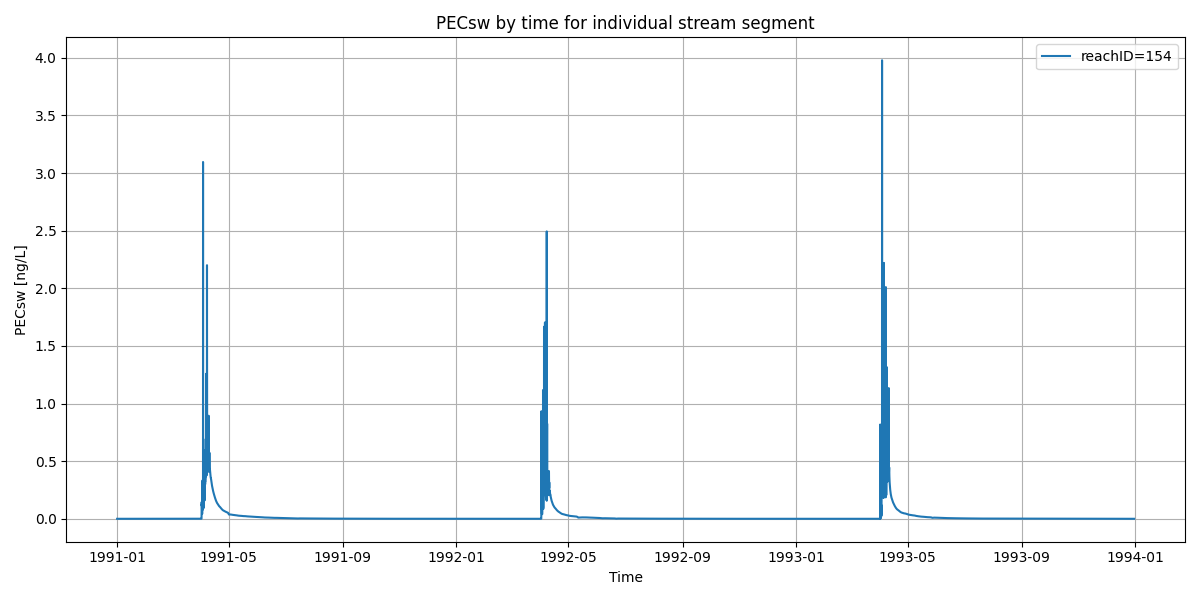

In [30]:
# Set figure size: (width, height)
plt.figure(figsize=(12, 6))  # Wider and shorter

# Customize the plot
#plt.style.use('fivethirtyeight')  # or 'seaborn', 'classic', 'fivethirtyeight', etc. 'ggplot'

# Plot each line separately in the same plot
#[1388, 1610, 1738, 1505]
#[315 230 151 149 735]
reachID = reach_list_PEC_plot_timeseries[0]
sns.lineplot(data=df_pecsw, x='time', y=reachID, label=f'reachID={reachID}')
#plt.legend(title='Reach-ID', fontsize='medium', loc='best')
plt.title('PECsw by time for individual stream segment')
plt.xlabel('Time')
plt.ylabel('PECsw [ng/L]')
plt.grid(True)
plt.tight_layout()
plt.show()

#save figure
#plt.savefig("scatter_plot_highres.png", dpi=300, bbox_inches='tight', transparent=True)
plt.savefig("PECsw_timeSeries_full_r" + str(reachID) + ".png")  # You can use .jpg, .pdf, .svg, etc.

Catchment Outlet - 3rd year zoomed-in time series

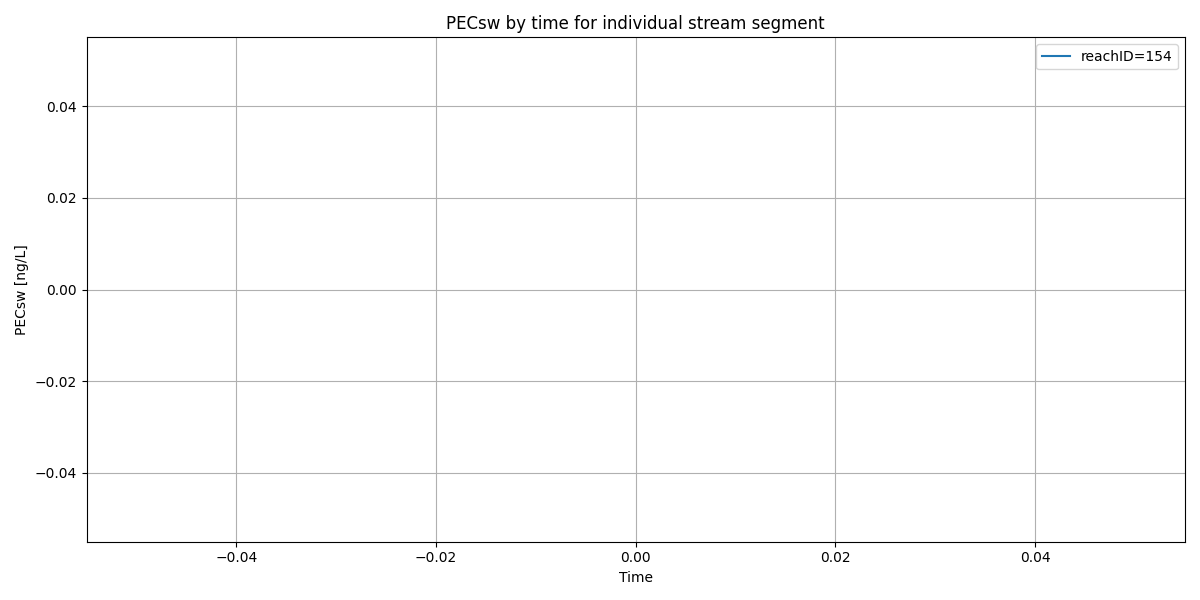

In [31]:
# Set figure size: (width, height)
plt.figure(figsize=(12, 6))  # Wider and shorter

# Create the line plot
#sns.lineplot(data=df, x='time', y=12)

# Customize the plot
#plt.style.use('fivethirtyeight')  # or 'seaborn', 'classic', 'fivethirtyeight', etc. 'ggplot'

# Plot each line separately in the same plot

reachID = reach_list_PEC_plot_timeseries[0]
# Slice between two dates
#subset = df_pecsw['2000-05-01':'2000-06-01']
subset = df_pecsw[plotzoom_from_time:plotzoom_to_time]
sns.lineplot(data=subset, x='time', y=reachID, label=f'reachID={reachID}')
#plt.legend(title='Reach-ID', fontsize='medium', loc='best')
plt.title('PECsw by time for individual stream segment')
plt.xlabel('Time')
plt.ylabel('PECsw [ng/L]')
plt.grid(True)
plt.tight_layout()
plt.show()

#save figure
#plt.savefig("scatter_plot_highres.png", dpi=300, bbox_inches='tight', transparent=True)
plt.savefig("PECsw_timeSeries_extract1_r" + str(reachID) + ".png")  # You can use .jpg, .pdf, .svg, etc.

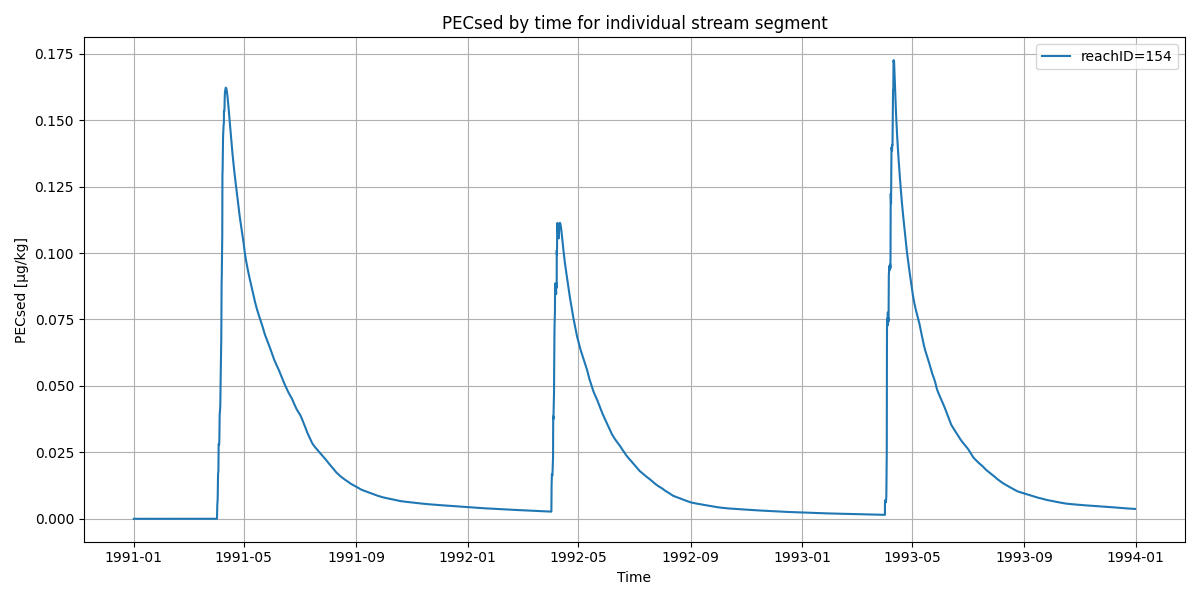

In [32]:
# Set figure size: (width, height)
plt.figure(figsize=(12, 6))  # Wider and shorter

# Create the line plot
#sns.lineplot(data=df, x='time', y=12)

# Customize the plot
#plt.style.use('fivethirtyeight')  # or 'seaborn', 'classic', 'fivethirtyeight', etc. 'ggplot'

# Plot each line separately in the same plot
#Rummen: 1388 1610 1738 1505
#Muschenheim: 315 230 151 149 735
reachID = reach_list_PEC_plot_timeseries[0]
sns.lineplot(data=df_pecsed, x='time', y=reachID, label=f'reachID={reachID}')
#plt.legend(title='Reach-ID', fontsize='medium', loc='best')
plt.title('PECsed by time for individual stream segment')
plt.xlabel('Time')
plt.ylabel('PECsed [µg/kg]')
plt.grid(True)
plt.tight_layout()
plt.show()

#save figure
#plt.savefig("scatter_plot_highres.png", dpi=300, bbox_inches='tight', transparent=True)
plt.savefig("PECsed_timeSeries_full_r" + str(reachID) + ".png")  # You can use .jpg, .pdf, .svg, etc.

Catchment Outlet - 3rd year zoomed-in time series

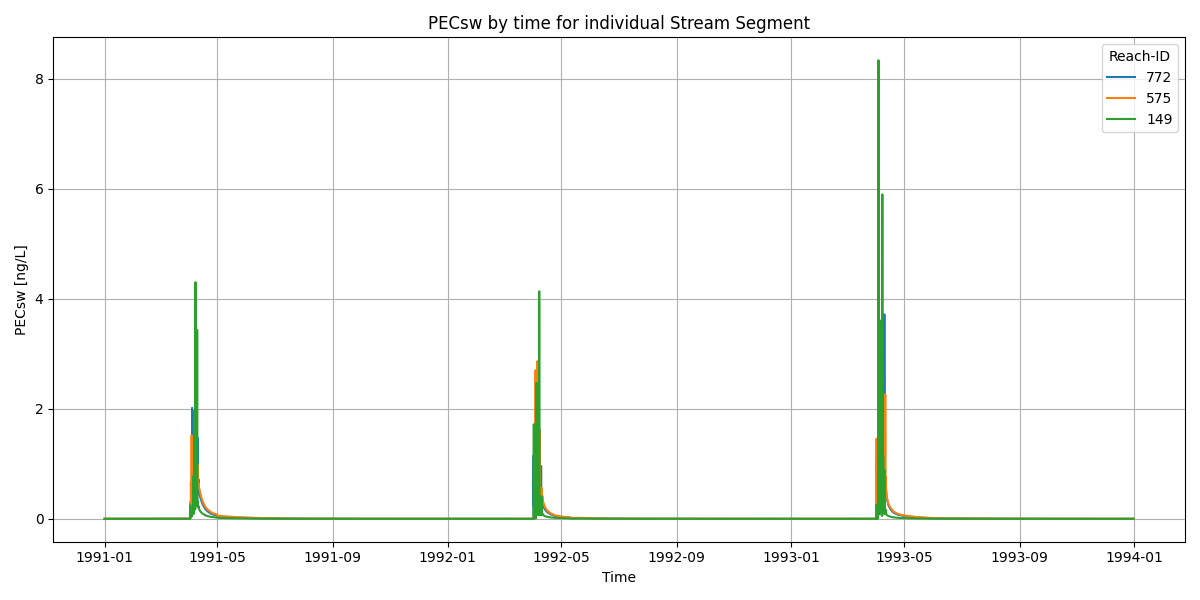

In [33]:
# Set figure size: (width, height)
plt.figure(figsize=(12, 6))  # Wider and shorter

# Create the line plot
#sns.lineplot(data=df, x='time', y=12)

# Customize the plot
#plt.style.use('fivethirtyeight')  # or 'seaborn', 'classic', 'fivethirtyeight', etc. 'ggplot'

# Plot each line in the same plot
for column in reach_list_PEC_groupplot_timeseries:
    sns.lineplot(data=df_pecsw, x='time', y=column, label=column)
plt.legend(title='Reach-ID', fontsize='medium', loc='best')
plt.title('PECsw by time for individual Stream Segment')
plt.xlabel('Time')
plt.ylabel('PECsw [ng/L]')
plt.grid(True)
plt.tight_layout()
plt.show()

#save figure
#plt.savefig("scatter_plot_highres.png", dpi=300, bbox_inches='tight', transparent=True)
plt.savefig("PECsw_timeSeries_full_r" + str(reach_list_PEC_groupplot_timeseries) + ".png")  # You can use .jpg, .pdf, .svg, etc.

## Introduce Stream Network Strahler Order to Analysis

prepare GUTS data to assign to geospatial data

In [34]:
#transpose data to make ReachID first column and index
df_guts_survival_sd_species1_T = df_guts_survival_sd_species1.transpose()
#df_guts_survival_sd_species1_T = df_guts_survival_sd_species1_T.rename(columns={'time': 'ReachID'})
df_guts_survival_sd_species1_T.index.name = 'ReachID'
df_guts_survival_sd_species1_T

time,1991-12-31,1992-12-31,1993-12-31
ReachID,,,
1,1.000000,1.000000,1.000000
10,1.000000,1.000000,1.000000
100,0.902848,0.995046,0.973449
1000,1.000000,1.000000,1.000000
1001,1.000000,1.000000,1.000000
...,...,...,...
995,1.000000,1.000000,1.000000
996,1.000000,1.000000,1.000000
997,1.000000,1.000000,1.000000


In [35]:
#transpose data to make ReachID first column and index
df_guts_LP50_sd_species1_T = df_guts_LP50_sd_species1.transpose()
#df_guts_survival_sd_species1_T = df_guts_survival_sd_species1_T.rename(columns={'time': 'ReachID'})
df_guts_LP50_sd_species1.index.name = 'ReachID'
df_guts_LP50_sd_species1_T

ReachID,1991-12-31,1992-12-31,1993-12-31
1,1000.000000,1000.000000,1000.000000
10,1000.000000,1000.000000,1000.000000
100,4.148875,8.275142,10.971793
1000,1000.000000,1000.000000,1000.000000
1001,1000.000000,1000.000000,1000.000000
...,...,...,...
995,1000.000000,1000.000000,1000.000000
996,1000.000000,1000.000000,1000.000000
997,1000.000000,1000.000000,1000.000000
998,1000.000000,1000.000000,1000.000000


In [36]:
# Load the shapefile
df_geo_reaches = gpd.read_file(scenario_path + '\\' + 'geo\\' + "Reachlist_shp.shp")
# Access the attribute table as a DataFrame
df_scenario_geo_attributes = df_geo_reaches.drop(columns='geometry')  # Optional: remove geometry if not needed

pecsw_percentiles_byReachOverTime_transposed = pecsw_percentiles_byReachOverTime.transpose()
pecsw_percentiles_byReachOverTime_transposed.index.name = 'ReachID'

# join 'strahler' attribute column to pecsw_percentiles table
# Set 'key' as index in the other DataFrame
df_scenario_geo_attributes.set_index('key', inplace=True)
# Join 'strahler' column to PECsw using index
pecsw_percentiles_byReachOverTime_transposed = pecsw_percentiles_byReachOverTime_transposed.join(df_scenario_geo_attributes['strahler'])

#print(df_scenario_geo_attributes.head())

...for LP50_sd_species1

In [37]:
# Join 'strahler' column to LP50 using index
df_guts_LP50_sd_species1_T = df_guts_LP50_sd_species1_T.join(df_scenario_geo_attributes['strahler'], how='left')

# Convert column names to year strings
df_guts_LP50_sd_species1_T.columns = [str(col.year) if isinstance(col, pd.Timestamp) else str(col) for col in df_guts_LP50_sd_species1_T.columns]


In [38]:
df_guts_LP50_sd_species1_T

,1991,1992,1993,strahler
1,1000.000000,1000.000000,1000.000000,1
10,1000.000000,1000.000000,1000.000000,2
100,4.148875,8.275142,10.971793,3
1000,1000.000000,1000.000000,1000.000000,1
1001,1000.000000,1000.000000,1000.000000,1
...,...,...,...,...
995,1000.000000,1000.000000,1000.000000,1
996,1000.000000,1000.000000,1000.000000,1
997,1000.000000,1000.000000,1000.000000,1
998,1000.000000,1000.000000,1000.000000,1


prepare LP50 data for bin counts heatmap

In [39]:
df = df_guts_LP50_sd_species1_T

# Example setup
bins = [-float('inf'),0.1, 1, 10, 100, 200, 500, 1000]
#bin_labels = [f"{bins[i]}–{bins[i+1]}" for i in range(len(bins)-1)]
bin_labels = [str(bin) for bin in bins]
bin_labels = [
    "<0.1",
    "[0.1, 1)",
    "[1, 10)",
    "[10, 100)",
    "[100, 200)",
    "[200, 500)",
    "[500, 1000]"
]

# Create a dictionary to store results
grouped_counts = {}

# Loop through each data column (excluding 'strahler')
for col in df.columns.drop('strahler'):
    # Bin the data
    binned = pd.cut(df[col], bins=bins, labels=bin_labels, right=False)    #include_lowest=True

    # Group by 'strahler' and count values in each bin
    counts = df.groupby('strahler')[col].apply(lambda x: pd.cut(x, bins=bins, labels=bin_labels, include_lowest=True).value_counts()).unstack().fillna(0)

    # Store result
    grouped_counts[col] = counts

combined = pd.concat(grouped_counts, axis=1)

In [40]:
combined

1991                                                               \
         <0.1 [0.1, 1) [1, 10) [10, 100) [100, 200) [200, 500) [500, 1000]   
strahler                                                                     
1           3       58     160        70          8          2         219   
2           0       72     119        13          5          0          83   
3           0       44     114        71          0          0           6   
4           0        0      63         0          0          0           0   
5           0        0       7         0          0          0           0   

         1992                   ...                                   1993  \
         <0.1 [0.1, 1) [1, 10)  ... [100, 200) [200, 500) [500, 1000] <0.1   
strahler                        ...                                          
1           6       76     125  ...         10         11         221    3   
2           0       31     136  ...          4          0          86    0   
3           0       12     144  ...          0          1           5    0   
4           0        0      63  ...          0          0           0    0   
5           0        0       7  ...          0          0           0    0   

                                                                       
         [0.1, 1) [1, 10) [10, 100) [100, 200) [200, 500) [500, 1000]  
strahler                                                               
1              54     141        69          8          9         232  
2              18     136        39          0          0          97  
3               0     123        56          1          0          31  
4               0      63         0          0          0           0  
5               0       7         0          0          0           0  

[5 rows x 21 columns]

In [41]:
# Assuming 'combined' is your multi-indexed DataFrame:
# Level 0: feature name
# Level 1: bin label
# Rows: 'strahler' groups

# Set up the plot grid
features = combined.columns.levels[0]

In [42]:
#plot all individual graphs in 1 column
'''
# Assuming 'combined' is your multi-indexed DataFrame:
# Level 0: feature name
# Level 1: bin label
# Rows: 'strahler' groups

# Set up the plot grid
features = combined.columns.levels[0]
num_features = len(features)
fig, axes = plt.subplots(nrows=num_features, figsize=(10, 4 * num_features), constrained_layout=True)

# If there's only one feature, axes won't be iterable
if num_features == 1:
    axes = [axes]

# Loop through each feature and plot heatmap
for ax, feature in zip(axes, features):
    data = combined[feature]

    sns.heatmap(
        data,
        annot=True,
        fmt='g',
        cmap='YlGnBu',
        cbar=True,
        ax=ax
    )

    ax.set_title(f"Bin Counts for Feature: {feature}", fontsize=14)
    ax.set_xlabel("Bin Range")
    ax.set_ylabel("Strahler Group")

plt.show()

plt.savefig("LP50stats_by_Strahler_1__sd_species1.png")  # You can use .jpg, .pdf, .svg, etc.
'''

'\n# Assuming \'combined\' is your multi-indexed DataFrame:\n# Level 0: feature name\n# Level 1: bin label\n# Rows: \'strahler\' groups\n\n# Set up the plot grid\nfeatures = combined.columns.levels[0]\nnum_features = len(features)\nfig, axes = plt.subplots(nrows=num_features, figsize=(10, 4 * num_features), constrained_layout=True)\n\n# If there\'s only one feature, axes won\'t be iterable\nif num_features == 1:\n    axes = [axes]\n\n# Loop through each feature and plot heatmap\nfor ax, feature in zip(axes, features):\n    data = combined[feature]\n\n    sns.heatmap(\n        data,\n        annot=True,\n        fmt=\'g\',\n        cmap=\'YlGnBu\',\n        cbar=True,\n        ax=ax\n    )\n\n    ax.set_title(f"Bin Counts for Feature: {feature}", fontsize=14)\n    ax.set_xlabel("Bin Range")\n    ax.set_ylabel("Strahler Group")\n\nplt.show()\n\nplt.savefig("LP50stats_by_Strahler_1__sd_species1.png")  # You can use .jpg, .pdf, .svg, etc.\n'

Heatmaps for LP50 value counts by Strahler order

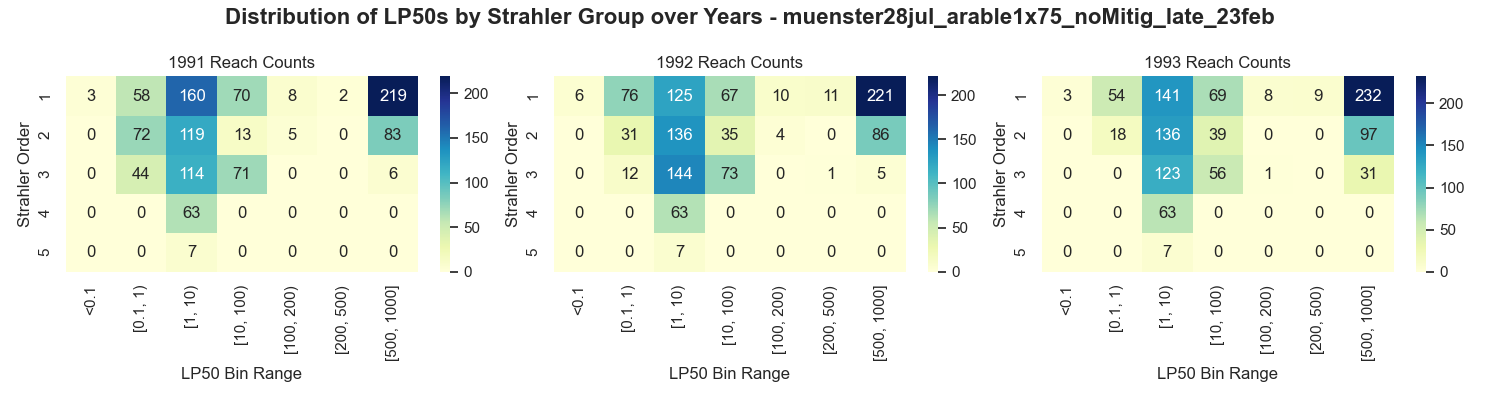

In [43]:
# Example setup — replace this with your actual 'combined' DataFrame
# Assume 'combined' has MultiIndex columns: (feature, bin_range)
# Rows are 'strahler' groups

# Sample synthetic data for demonstration


# Seaborn style
sns.set_theme(style='whitegrid')

# Grid layout: 3 columns, flexible rows
num_features = len(features)
cols = 3
rows = int(np.ceil(num_features / cols))

# Create subplots
fig, axes = plt.subplots(rows, cols, figsize=(cols * 5, rows * 4))
axes = axes.flatten()

# Plot each feature's heatmap
for i, feature in enumerate(features):
    ax = axes[i]
    heatmap_data = combined[feature]
    sns.heatmap(
        heatmap_data,
        annot=True,
        fmt="d",
        cmap="YlGnBu",
        ax=ax,
        cbar=True
    )
    ax.set_title(f"{feature} Reach Counts")
    ax.set_xlabel("LP50 Bin Range")
    ax.set_ylabel("Strahler Order")

# Hide unused subplots
for j in range(num_features, len(axes)):
    fig.delaxes(axes[j])

# Final layout
# Add overall title
fig.suptitle("Distribution of LP50s by Strahler Group over Years - " + experiment, fontsize=16, fontweight='bold')
plt.tight_layout(rect=(0, 0.1, 1, 0.95))  # Leave space at top for title, # Adjust layout so title doesn't overlap
plt.tight_layout()
plt.show()

plt.savefig("LP50stats_by_Strahler_1__sd_species1_2.png")  # You can use .jpg, .pdf, .svg, etc.


In [44]:
grouped_counts

{'1991':           <0.1  [0.1, 1)  [1, 10)  [10, 100)  [100, 200)  [200, 500)  \
 strahler                                                               
 1            3        58      160         70           8           2   
 2            0        72      119         13           5           0   
 3            0        44      114         71           0           0   
 4            0         0       63          0           0           0   
 5            0         0        7          0           0           0   
 
           [500, 1000]  
 strahler               
 1                 219  
 2                  83  
 3                   6  
 4                   0  
 5                   0  ,
 '1992':           <0.1  [0.1, 1)  [1, 10)  [10, 100)  [100, 200)  [200, 500)  \
 strahler                                                               
 1            6        76      125         67          10          11   
 2            0        31      136         35           4           0   
 3 

In [45]:
pecsw_percentiles_byReachOverTime_transposed

,0.1,0.25,0.5,0.75,0.9,0.95,0.99,1.0,strahler
ReachID,,,,,,,,,
1,0.000000,0.000000,0.000000,0.00000,0.00000,0.000000,0.000000,0.00000,1
10,0.000000,0.000000,0.000000,0.00000,0.00000,0.000000,0.000000,0.00000,2
100,0.000003,0.000014,0.000068,0.00067,0.00506,0.014948,0.129469,1.83939,3
1000,0.000000,0.000000,0.000000,0.00000,0.00000,0.000000,0.000000,0.00000,1
1001,0.000000,0.000000,0.000000,0.00000,0.00000,0.000000,0.000000,0.00000,1
...,...,...,...,...,...,...,...,...,...
995,0.000000,0.000000,0.000000,0.00000,0.00000,0.000000,0.000000,0.00000,1
996,0.000000,0.000000,0.000000,0.00000,0.00000,0.000000,0.000000,0.00000,1
997,0.000000,0.000000,0.000000,0.00000,0.00000,0.000000,0.000000,0.00000,1


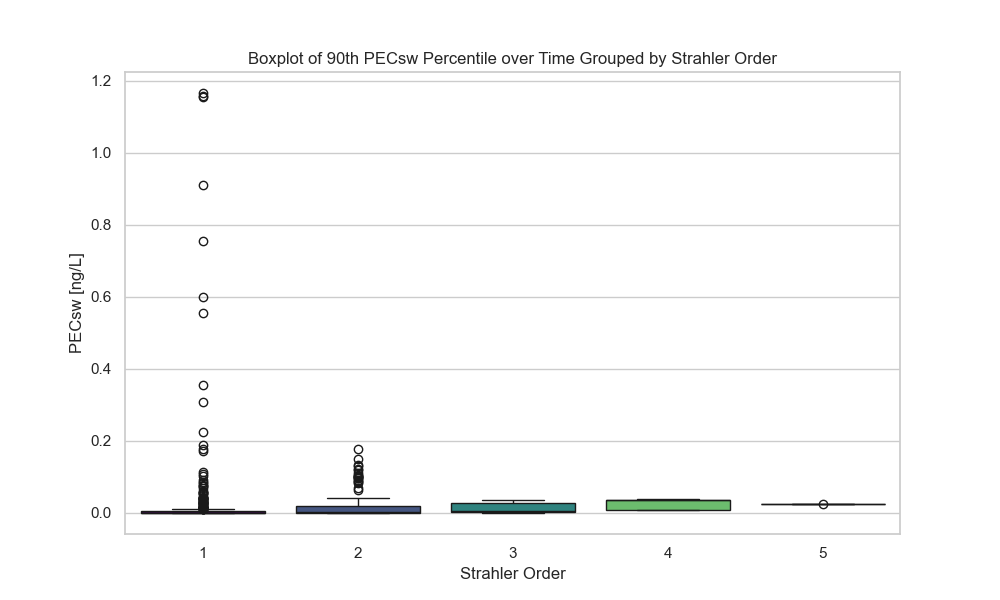

In [46]:
# prep datatable
#PECsw['strahler'] = PECsw['strahler'].astype(str)

plt.clf()
plt.close()

# Set seaborn style
sns.set_theme(style="whitegrid")

# Create the violin plot
plt.figure(figsize=(10, 6))
#sns.violinplot(x='strahler', y=0.9, data=pecsw_percentiles_byReachOverTime_transposed, palette='viridis')
#sns.violinplot(x='strahler', y=0.9, hue='strahler', data=pecsw_percentiles_byReachOverTime_transposed, palette='viridis', legend=False)
# Swarm plot overlay
#sns.swarmplot(x='strahler', y=0.9, data=pecsw_percentiles_byReachOverTime_transposed, color='k', size=3)

# Create the boxplot
sns.boxplot(x='strahler', y=boxplot_temporal_percentile[0], hue='strahler', data=pecsw_percentiles_byReachOverTime_transposed, palette='viridis', legend=False)

# Customize labels and title
plt.title("Boxplot of " + str(int(boxplot_temporal_percentile[0]*100)) + "th PECsw Percentile over Time Grouped by Strahler Order")
plt.xlabel("Strahler Order")
plt.ylabel("PECsw [ng/L]")

# Show the plot
plt.show()

#save figure
#plt.savefig("scatter_plot_highres.png", dpi=300, bbox_inches='tight', transparent=True)
plt.savefig("PECsw_" + str(int(boxplot_temporal_percentile[0]*100)) + "thPercentileOverTime_by_Strahler_1.png")  # You can use .jpg, .pdf, .svg, etc.

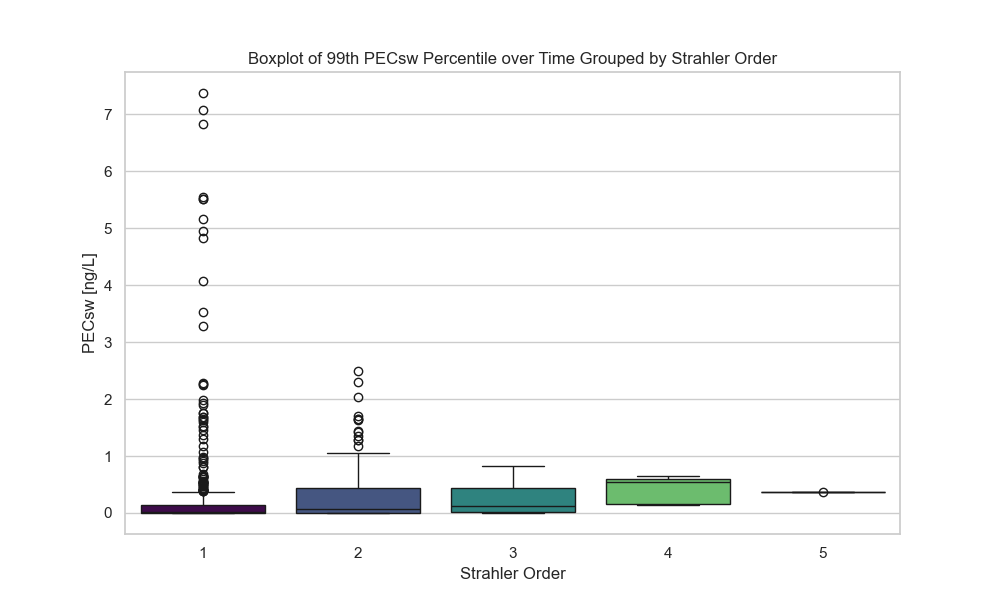

In [47]:
# prep datatable
#PECsw['strahler'] = PECsw['strahler'].astype(str)

plt.clf()
plt.close()

# Set seaborn style
sns.set_theme(style="whitegrid")

# Create the violin plot
plt.figure(figsize=(10, 6))
#sns.violinplot(x='strahler', y=0.9, data=pecsw_percentiles_byReachOverTime_transposed, palette='viridis')
#sns.violinplot(x='strahler', y=0.9, hue='strahler', data=pecsw_percentiles_byReachOverTime_transposed, palette='viridis', legend=False)
# Swarm plot overlay
#sns.swarmplot(x='strahler', y=0.9, data=pecsw_percentiles_byReachOverTime_transposed, color='k', size=3)

# Create the boxplot
sns.boxplot(x='strahler', y=boxplot_temporal_percentile[1], hue='strahler', data=pecsw_percentiles_byReachOverTime_transposed, palette='viridis', legend=False)

# Customize labels and title
plt.title("Boxplot of " + str(int(boxplot_temporal_percentile[1]*100)) + "th PECsw Percentile over Time Grouped by Strahler Order")
plt.xlabel("Strahler Order")
plt.ylabel("PECsw [ng/L]")

# Show the plot
plt.show()

#save figure
#plt.savefig("scatter_plot_highres.png", dpi=300, bbox_inches='tight', transparent=True)
#fig.canvas.draw()  # Ensures the canvas is rendered
#fig.savefig("plot.jpg")
# Access the current figure and force a canvas draw
#fig = plt.gcf()  # Get current figure
#fig.canvas.draw()
#plt.savefig("plot.jpg")


plt.savefig("PECsw_" + str(int(boxplot_temporal_percentile[1]*100)) + "thPercentileOverTime_by_Strahler_1.png")  # You can use .jpg, .pdf, .svg, etc.

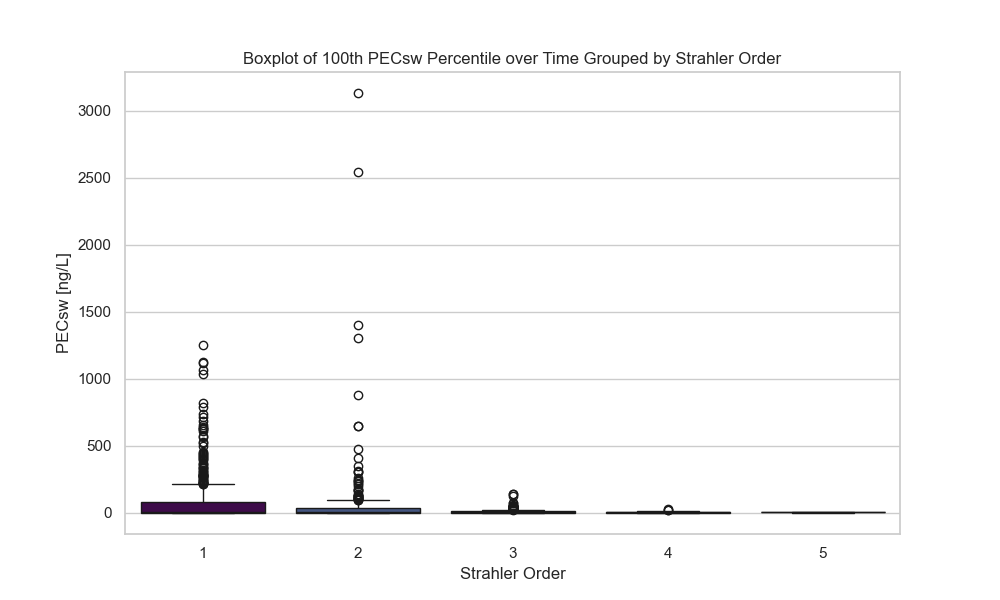

In [48]:
# prep datatable
#PECsw['strahler'] = PECsw['strahler'].astype(str)

plt.clf()
plt.close()

# Set seaborn style
sns.set_theme(style="whitegrid")

# Create the violin plot
plt.figure(figsize=(10, 6))
#sns.violinplot(x='strahler', y=0.9, data=pecsw_percentiles_byReachOverTime_transposed, palette='viridis')
#sns.violinplot(x='strahler', y=0.9, hue='strahler', data=pecsw_percentiles_byReachOverTime_transposed, palette='viridis', legend=False)
# Swarm plot overlay
#sns.swarmplot(x='strahler', y=0.9, data=pecsw_percentiles_byReachOverTime_transposed, color='k', size=3)

# Create the boxplot
sns.boxplot(x='strahler', y=boxplot_temporal_percentile[2], hue='strahler', data=pecsw_percentiles_byReachOverTime_transposed, palette='viridis', legend=False)

# Customize labels and title
plt.title("Boxplot of " + str(int(boxplot_temporal_percentile[2]*100)) + "th PECsw Percentile over Time Grouped by Strahler Order")
plt.xlabel("Strahler Order")
plt.ylabel("PECsw [ng/L]")

# Show the plot
plt.show()

#save figure
#plt.savefig("scatter_plot_highres.png", dpi=300, bbox_inches='tight', transparent=True)
#fig.canvas.draw()  # Ensures the canvas is rendered
#fig.savefig("plot.jpg")
# Access the current figure and force a canvas draw
#fig = plt.gcf()  # Get current figure
#fig.canvas.draw()
#plt.savefig("plot.jpg")


plt.savefig("PECsw_" + str(int(boxplot_temporal_percentile[2]*100)) + "thPercentileOverTime_by_Strahler_1.png")  # You can use .jpg, .pdf, .svg, etc.

### Survival Plots

prep survival data

### LP50 Plots

set bounderies to LP50 values

LP50 Histograms

In [49]:
'''plt.clf()
plt.close()

custom_bins = [0.1, 1, 10, 20, 50, 100, 200, 500, 1000]
# Bin the data manually
binned = pd.cut(df_guts_LP50_sd_species1_T[df_guts_LP50_sd_species1_T.columns[2]], bins=custom_bins)

# Count occurrences per bin
bin_counts = binned.value_counts().sort_index()

# Convert to strings for better x-axis labels
bin_labels = bin_counts.index.astype(str)

sns.barplot(x=bin_labels, y=bin_counts.values)
plt.xticks(rotation=45)
plt.show()
'''

'plt.clf()\nplt.close()\n\ncustom_bins = [0.1, 1, 10, 20, 50, 100, 200, 500, 1000]\n# Bin the data manually\nbinned = pd.cut(df_guts_LP50_sd_species1_T[df_guts_LP50_sd_species1_T.columns[2]], bins=custom_bins)\n\n# Count occurrences per bin\nbin_counts = binned.value_counts().sort_index()\n\n# Convert to strings for better x-axis labels\nbin_labels = bin_counts.index.astype(str)\n\nsns.barplot(x=bin_labels, y=bin_counts.values)\nplt.xticks(rotation=45)\nplt.show()\n'

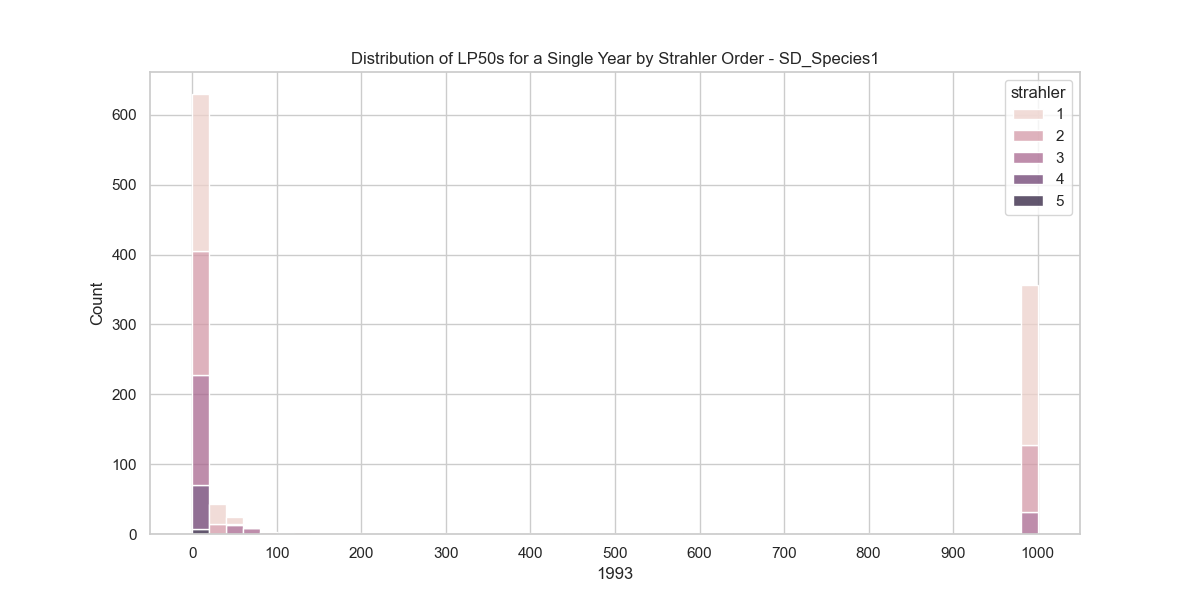

In [50]:
plt.clf()
plt.close()

# Set seaborn style
sns.set_theme(style="whitegrid")

plt.figure(figsize=(12, 6))
#bins = bins=[1, 10, 20, 50, 100, 200, 500, 1000]
sns.histplot(data=df_guts_LP50_sd_species1_T, x=df_guts_LP50_sd_species1_T[df_guts_LP50_sd_species1_T.columns[2]], hue="strahler", multiple="stack", bins=50)

# Customize labels and title
plt.title("Distribution of LP50s for a Single Year by Strahler Order - " + "SD_Species1")
plt.gca().xaxis.set_major_locator(ticker.MultipleLocator(100))
plt.show()

#save figure
#plt.savefig("scatter_plot_highres.png", dpi=300, bbox_inches='tight', transparent=True)
plt.savefig("LP50_Histogram_byStrahler - SD_Species1.png")  # You can use .jpg, .pdf, .svg, etc.

### Mapping

In [51]:
pecsw_percentiles_byReachOverTime_transposed

,0.1,0.25,0.5,0.75,0.9,0.95,0.99,1.0,strahler
ReachID,,,,,,,,,
1,0.000000,0.000000,0.000000,0.00000,0.00000,0.000000,0.000000,0.00000,1
10,0.000000,0.000000,0.000000,0.00000,0.00000,0.000000,0.000000,0.00000,2
100,0.000003,0.000014,0.000068,0.00067,0.00506,0.014948,0.129469,1.83939,3
1000,0.000000,0.000000,0.000000,0.00000,0.00000,0.000000,0.000000,0.00000,1
1001,0.000000,0.000000,0.000000,0.00000,0.00000,0.000000,0.000000,0.00000,1
...,...,...,...,...,...,...,...,...,...
995,0.000000,0.000000,0.000000,0.00000,0.00000,0.000000,0.000000,0.00000,1
996,0.000000,0.000000,0.000000,0.00000,0.00000,0.000000,0.000000,0.00000,1
997,0.000000,0.000000,0.000000,0.00000,0.00000,0.000000,0.000000,0.00000,1


In [52]:
df_geo_reaches_GUTS = df_geo_reaches.copy()

In [53]:
# Merge PECsw data into the GeoDataFrame
# Merge '0.9' column from PECsw into gdf using key columns
#pecsw_percentiles_byReachOverTime_transposed = pecsw_percentiles_byReachOverTime_transposed.reset_index()
df_geo_reaches = df_geo_reaches.merge(pecsw_percentiles_byReachOverTime_transposed[pec_temporal_percentiles], left_on='key', right_on='ReachID', how='left')

In [54]:
# Reformat column names: keep first column, convert rest to year
new_columns = [str(pd.to_datetime(col).year) for col in df_guts_survival_sd_species1_T.columns[0:]]
#str(df_guts_survival_sd_species1_T.columns[1].year)
#new_columns
df_guts_survival_sd_species1_T.columns = new_columns

df_guts_survival_sd_species1_T

,1991,1992,1993
ReachID,,,
1,1.000000,1.000000,1.000000
10,1.000000,1.000000,1.000000
100,0.902848,0.995046,0.973449
1000,1.000000,1.000000,1.000000
1001,1.000000,1.000000,1.000000
...,...,...,...
995,1.000000,1.000000,1.000000
996,1.000000,1.000000,1.000000
997,1.000000,1.000000,1.000000


In [55]:
df_geo_reaches_GUTS = df_geo_reaches_GUTS.merge(df_guts_survival_sd_species1_T, left_on='key', right_on='ReachID', how='left')


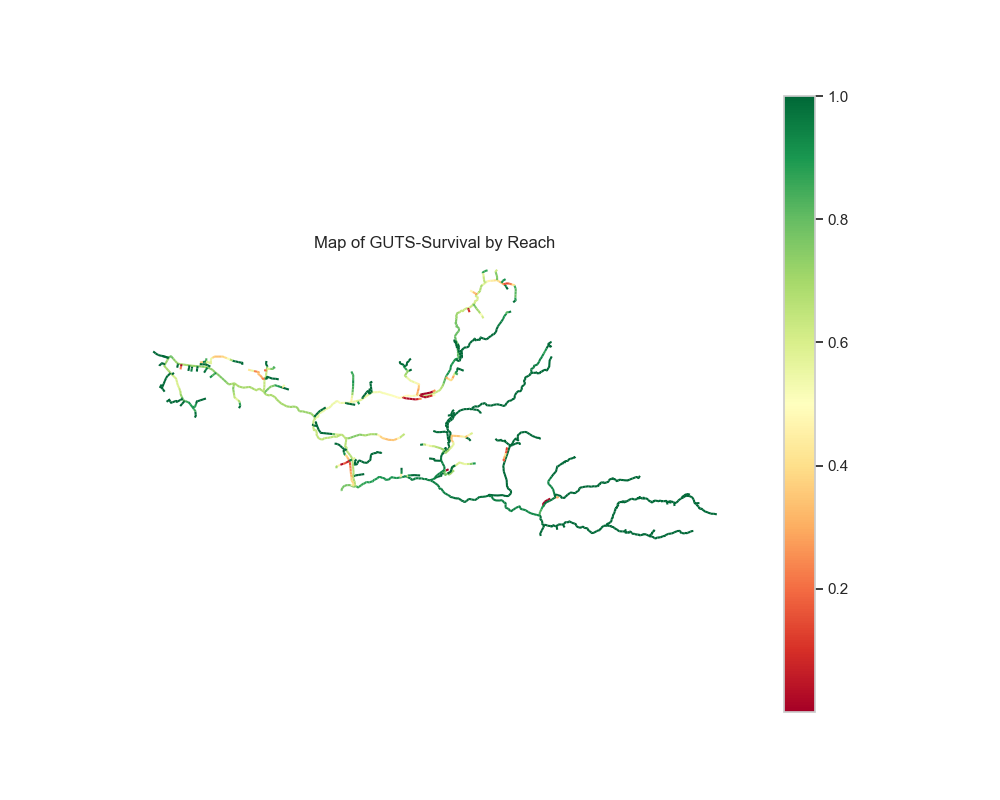

In [56]:
# Plot the map colored by the new '0.9' column. take the last simulation year
df_geo_reaches_GUTS.plot(column=df_guts_survival_sd_species1_T.columns[-1], cmap='RdYlGn', legend=True, figsize=(10, 8))

plt.title("Map of GUTS-Survival by Reach")
plt.axis('off')
plt.show()

In [57]:
#save figure
#plt.savefig("scatter_plot_highres.png", dpi=300, bbox_inches='tight', transparent=True)
plt.savefig("GUTS_survival_sd_species1_1995_Map_1.png")  # You can use .jpg, .pdf, .svg, etc.

In [58]:
#df_geo_reaches.columns = df_geo_reaches.columns.astype(str)
#print(df_geo_reaches.columns.tolist())

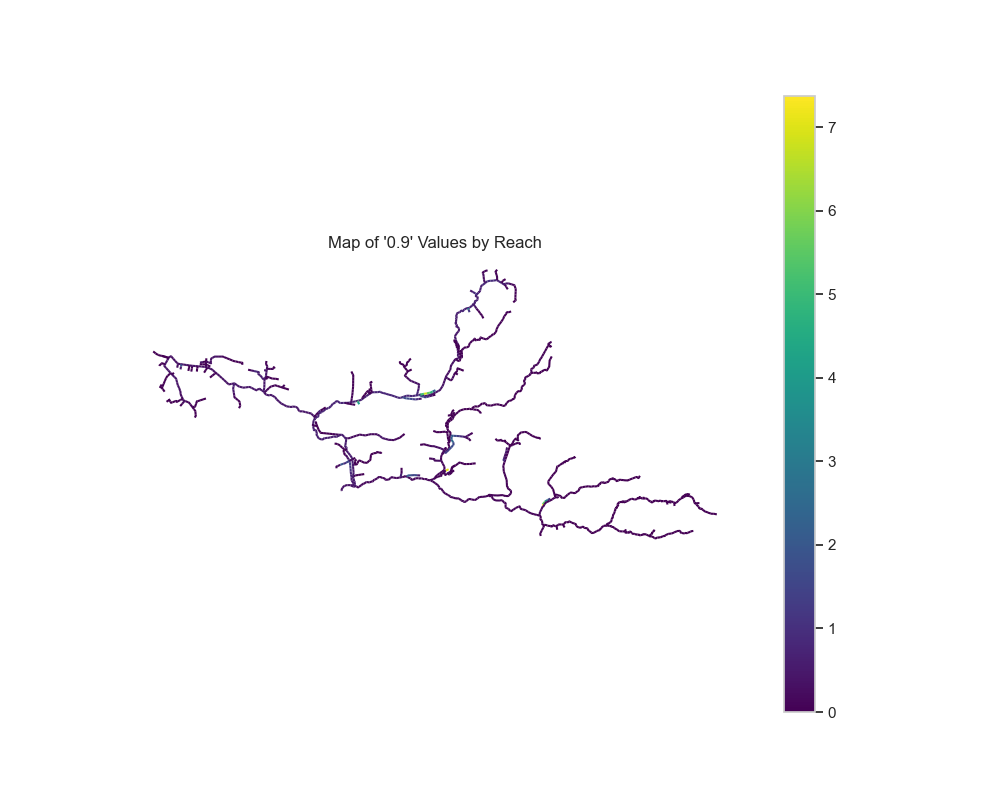

In [59]:


# Plot the map colored by the new '0.9' column
df_geo_reaches.plot(column=0.99, cmap='viridis', legend=True, figsize=(10, 8))

plt.title("Map of '0.9' Values by Reach")
plt.axis('off')
plt.show()


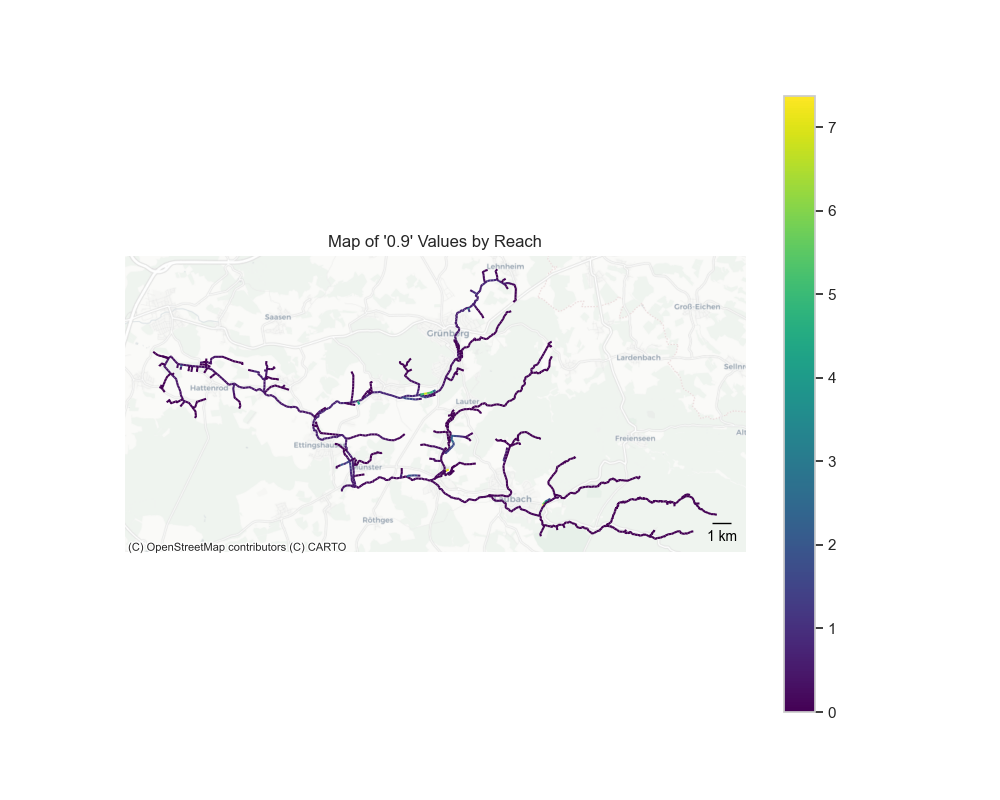

In [60]:
# 1) reproject to a metric CRS
gdf_m = df_geo_reaches.to_crs(epsg=3857)

# 2) plot
ax = gdf_m.plot(
    column=0.99,
    cmap='viridis',
    legend=True,
    figsize=(10, 8)
)
ax.set_title("Map of '0.9' Values by Reach")
ax.axis('off')

# Add ESRI Gray basemap
#ctx.add_basemap(ax, source=ctx.providers.Esri.WorldGrayCanvas)
ctx.add_basemap(ax, source=ctx.providers.CartoDB.Positron)
#alternative code:
#import contextily as ctx
#import xyzservices.providers as xyz
#ctx.add_basemap(ax, source=xyz.Esri.WorldGrayCanvas)

#show providers:
#import xyzservices.providers as xyz
#print(dir(xyz))

# 3) create a scalebar: 1000 m long, labelled “1 km”
fontprops = fm.FontProperties(size=10)
scalebar = AnchoredSizeBar(
    ax.transData,
    size=1000,                # length of the bar in map units (m)
    label='1 km',             # text label
    loc='lower right',        # position
    pad=0.3,                  # padding around the bar
    borderpad=0.3,            # padding between bar and text
    sep=5,                    # space between bar and text
    frameon=False,
    fontproperties=fontprops
)
ax.add_artist(scalebar)

plt.show()

In [61]:
#save figure
#plt.savefig("scatter_plot_highres.png", dpi=300, bbox_inches='tight', transparent=True)
plt.savefig("PECsw_percentilesOverTime_Map_1.png")  # You can use .jpg, .pdf, .svg, etc.

In [62]:
import xyzservices.providers as xyz
print(dir(xyz))


['AzureMaps', 'BaseMapDE', 'BasemapAT', 'CartoDB', 'CyclOSM', 'Esri', 'FreeMapSK', 'Gaode', 'GeoportailFrance', 'HERE', 'HikeBike', 'Jawg', 'JusticeMap', 'MapBox', 'MapTiler', 'MapTilesAPI', 'MtbMap', 'NASAGIBS', 'NLS', 'OPNVKarte', 'OneMapSG', 'OpenAIP', 'OpenFireMap', 'OpenRailwayMap', 'OpenSeaMap', 'OpenSnowMap', 'OpenStreetMap', 'OpenTopoMap', 'OpenWeatherMap', 'OrdnanceSurvey', 'SafeCast', 'Stadia', 'Strava', 'SwissFederalGeoportal', 'Thunderforest', 'TomTom', 'TopPlusOpen', 'UN', 'USGS', 'WaymarkedTrails', 'nlmaps']
